In [1]:
import json
from pathlib import Path

DATA_DIR = Path("../data/raw")
METADATA_PATH = DATA_DIR / "DATA.json"

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print(type(metadata))

<class 'dict'>


In [2]:
print(metadata.keys())

dict_keys(['Astrocytoma T1\\T1 - Anaplastic astrocytoma (pineal region) 001.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma (pineal region) 002.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma (pineal region) 003.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma (pineal region) 004.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma frontal , ventricle 001.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma frontal , ventricle 002.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma frontal , ventricle 003.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma NOS 004.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma NOS 005.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma NOS 006.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma parietal , ventricle 001.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma parietal , ventricle 002.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma parietal , ventricle 003.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma parietal , ventricle 004.jpg',

In [3]:
print("Nombre d'entrées :", len(metadata))

first_key = next(iter(metadata))

print("\nPremière clé :")
print(first_key)

print("\nMétadonnées associées :")
print(metadata[first_key])

Nombre d'entrées : 11300

Première clé :
Astrocytoma T1\T1 - Anaplastic astrocytoma (pineal region) 001.jpg

Métadonnées associées :
{'width': 512, 'height': 512, 'point': {'x': 269, 'y': 286}, 'location': [], 'description': 'There is a mass in the quadrigeminal plate cistern, which is homogeneously mildly T2 hyper- and T1 hypointense to grey matter and demonstrates avid heterogeneous contrast enhancement. Abnormal signal also extends into the thalami, more marked on the right. The mass has high signal on DWI and low ADC values (diffusion restriction), likely indicating high cellularity.\n\nThere is increased blood volume in the lesion (not shown) and MRS shows increased choline-creatine ratio with reduced NAA peak and a small lipid/lactate peak in keeping with a higher-grade tumor.\n\nThere is obstruction of the cerebral aqueduct with hydrocephalus involving the lateral and third ventricles. Mild periventricular T2 hyperintensity suggests a degree of transependymal edema.', 'class': '

In [4]:
import pandas as pd

df = (
    pd.DataFrame.from_dict(metadata, orient="index")
    .rename_axis("image_path")
    .reset_index()
)

df.head()

,image_path,width,height,point,location,description,class
0,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,512,512,"{'x': 269, 'y': 286}",[],There is a mass in the quadrigeminal plate cis...,Astrocytoma T1
1,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,512,512,"{'x': 260, 'y': 291}",[],There is a mass in the quadrigeminal plate cis...,Astrocytoma T1
2,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,512,512,"{'x': 259, 'y': 299}",[],There is a mass in the quadrigeminal plate cis...,Astrocytoma T1
3,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,512,512,"{'x': 259, 'y': 305}",[],There is a mass in the quadrigeminal plate cis...,Astrocytoma T1
4,Astrocytoma T1\T1 - Anaplastic astrocytoma fro...,512,512,"{'x': 267, 'y': 158}","[frontal, ventricle]","There is a large, ill-defined region of white ...",Astrocytoma T1


In [5]:
df.shape

(11300, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11300 entries, 0 to 11299
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   image_path   11300 non-null  object
 1   width        11300 non-null  int64 
 2   height       11300 non-null  int64 
 3   point        11300 non-null  object
 4   location     11300 non-null  object
 5   description  11300 non-null  object
 6   class        11300 non-null  object
dtypes: int64(2), object(5)
memory usage: 618.1+ KB


In [7]:
print("Dimensions d'images :")
print(
    df[["width", "height"]]
    .value_counts()
)

print("\nNombre de classes :", df["class"].nunique())

print("\nEffectifs par classe :")
print(
    df["class"]
    .value_counts()
    .sort_index()
)

Dimensions d'images :
width  height
512    512       11300
Name: count, dtype: int64

Nombre de classes : 30

Effectifs par classe :
class
Astrocytoma T1             396
Astrocytoma T1C+           441
Astrocytoma T2             281
Ependymoma T1              313
Ependymoma T1C+            374
Ependymoma T2              350
Glioma T1                  522
Glioma T1C+                549
Glioma T2                  405
Hemangiopericytoma T1      178
Hemangiopericytoma T1C+    307
Hemangiopericytoma T2      118
Meningioma T1              636
Meningioma T1C+            977
Meningioma T2              458
Neurocytoma T1             190
Neurocytoma T1C+           254
Neurocytoma T2             174
Normal T1                  415
Normal T1C+                264
Normal T2                  379
Oligodendroglioma T1       221
Oligodendroglioma T1C+     192
Oligodendroglioma T2       137
Other T1                   412
Other T1C+                 756
Other T2                   365
Schwannoma T1           

In [ ]:
modalities = ["T1C+", "T1", "T2"]

def split_class(class_name):
    for modality in modalities:
        suffix = f" {modality}"
        if class_name.endswith(suffix):
            pathology = class_name[:-len(suffix)]
            return pathology, modality

    return class_name, None

df[["pathology", "modality"]] = (
    df["class"]
    .apply(split_class)
    .apply(pd.Series)
)

df[["class", "pathology", "modality"]].drop_duplicates().sort_values(
    ["pathology", "modality"]
)

,class,pathology,modality
0,Astrocytoma T1,Astrocytoma,T1
396,Astrocytoma T1C+,Astrocytoma,T1C+
837,Astrocytoma T2,Astrocytoma,T2
1118,Ependymoma T1,Ependymoma,T1
1431,Ependymoma T1C+,Ependymoma,T1C+
1805,Ependymoma T2,Ependymoma,T2
2155,Glioma T1,Glioma,T1
2677,Glioma T1C+,Glioma,T1C+
3226,Glioma T2,Glioma,T2
3631,Hemangiopericytoma T1,Hemangiopericytoma,T1


In [9]:
pd.crosstab(
    df["pathology"],
    df["modality"],
    margins=True
)

modality,T1,T1C+,T2,All
pathology,,,,
Astrocytoma,396,441,281,1118
Ependymoma,313,374,350,1037
Glioma,522,549,405,1476
Hemangiopericytoma,178,307,118,603
Meningioma,636,977,458,2071
Neurocytoma,190,254,174,618
Normal,415,264,379,1058
Oligodendroglioma,221,192,137,550
Other,412,756,365,1533


In [10]:
from pathlib import Path

# Tous les fichiers image réellement présents dans les 30 dossiers
image_files = list(DATA_DIR.rglob("*.jpg"))

print("Images physiques :", len(image_files))
print("Entrées DATA.json :", len(df))

Images physiques : 11300
Entrées DATA.json : 11300


In [11]:

json_paths = {
    str(Path(*path.split("\\")))
    for path in df["image_path"]
}

disk_paths = {
    str(path.relative_to(DATA_DIR))
    for path in image_files
}

missing_on_disk = json_paths - disk_paths
missing_in_json = disk_paths - json_paths

print("Référencées dans JSON mais absentes du disque :", len(missing_on_disk))
print("Présentes sur disque mais absentes du JSON :", len(missing_in_json))

Référencées dans JSON mais absentes du disque : 22
Présentes sur disque mais absentes du JSON : 22


In [12]:
print("=== JSON → fichier introuvable ===")
for path in sorted(missing_on_disk):
    print(repr(path))

print("\n=== Disque → entrée JSON introuvable ===")
for path in sorted(missing_in_json):
    print(repr(path))

=== JSON → fichier introuvable ===
'Glioma T1C+/T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 001.jpg'
'Glioma T1C+/T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 002.jpg'
'Glioma T1C+/T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 003.jpg'
'Glioma T1C+/T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 004.jpg'
'Glioma T1C+/T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 005.jpg'
'Glioma T1C+/T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 006.jpg'
'Glioma T1C+/T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 007.jpg'
'Glioma T1C+/T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 008.jpg'
'Glioma T1C+/T1C+ - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 009.jpg'
'Glioma T2/T2 - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 001.jpg'
'Glioma T2/T2 - Diffuse midline glioma, H3 K27M–mutant ventricle , frontal 002.jpg'
'Glio

In [13]:
def normalize_path(path):
    return path.replace("â€“", "–")

In [14]:
disk_paths_normalized = {
    normalize_path(str(path.relative_to(DATA_DIR)))
    for path in image_files
}

missing_on_disk_after_normalization = json_paths - disk_paths_normalized
missing_in_json_after_normalization = disk_paths_normalized - json_paths

print(
    "JSON → disque après normalisation :",
    len(missing_on_disk_after_normalization)
)

print(
    "Disque → JSON après normalisation :",
    len(missing_in_json_after_normalization)
)

JSON → disque après normalisation : 0
Disque → JSON après normalisation : 0


In [15]:
print("Points vides :", df["point"].apply(lambda x: not bool(x)).sum())
print("Locations vides :", df["location"].apply(lambda x: not bool(x)).sum())
print("Descriptions vides :", df["description"].apply(lambda x: not bool(x.strip())).sum())

print("\nTypes de point :")
print(df["point"].apply(type).value_counts())

print("\nTypes de location :")
print(df["location"].apply(type).value_counts())

Points vides : 0
Locations vides : 1988
Descriptions vides : 291

Types de point :
point
<class 'dict'>    11300
Name: count, dtype: int64

Types de location :
location
<class 'list'>    11300
Name: count, dtype: int64


In [16]:
df["location_empty"] = df["location"].apply(lambda x: not bool(x))
df["description_empty"] = df["description"].apply(
    lambda x: not bool(x.strip())
)

missing_metadata = pd.crosstab(
    df["pathology"],
    df["modality"],
    values=df["location_empty"],
    aggfunc="sum",
    margins=True
)

missing_metadata

modality,T1,T1C+,T2,All
pathology,,,,
Astrocytoma,61,55,33,149
Ependymoma,45,50,7,102
Glioma,135,138,97,370
Hemangiopericytoma,24,45,4,73
Meningioma,104,103,59,266
Neurocytoma,57,52,11,120
Normal,226,106,247,579
Oligodendroglioma,15,12,16,43
Other,91,46,71,208


In [17]:
missing_descriptions = pd.crosstab(
    df["pathology"],
    df["modality"],
    values=df["description_empty"],
    aggfunc="sum",
    margins=True
)

missing_descriptions

modality,T1,T1C+,T2,All
pathology,,,,
Astrocytoma,0,0,0,0
Ependymoma,0,0,0,0
Glioma,0,0,0,0
Hemangiopericytoma,0,0,0,0
Meningioma,0,0,0,0
Neurocytoma,0,0,0,0
Normal,69,0,36,105
Oligodendroglioma,0,0,0,0
Other,55,39,55,149


In [18]:
df["point_x"] = df["point"].apply(lambda p: p.get("x"))
df["point_y"] = df["point"].apply(lambda p: p.get("y"))

print("x manquants :", df["point_x"].isna().sum())
print("y manquants :", df["point_y"].isna().sum())

print("\nPlage de x :", df["point_x"].min(), "→", df["point_x"].max())
print("Plage de y :", df["point_y"].min(), "→", df["point_y"].max())

invalid_points = df[
    (df["point_x"] < 0)
    | (df["point_x"] >= df["width"])
    | (df["point_y"] < 0)
    | (df["point_y"] >= df["height"])
]

print("\nPoints hors image :", len(invalid_points))

x manquants : 0
y manquants : 0

Plage de x : 101 → 403
Plage de y : 65 → 460

Points hors image : 0


In [19]:
normal_points = (
    df.loc[df["pathology"] == "Normal", ["point_x", "point_y"]]
    .value_counts()
)

print("Nombre d'images Normal :", (df["pathology"] == "Normal").sum())
print("Nombre de coordonnées différentes :", len(normal_points))

print("\nCoordonnées les plus fréquentes :")
print(normal_points.head(10))

Nombre d'images Normal : 1058
Nombre de coordonnées différentes : 39

Coordonnées les plus fréquentes :
point_x  point_y
258      276        116
252      258         80
255      245         70
253      247         64
256      246         64
253      246         62
250      253         59
255      264         44
253      242         42
252      257         41
Name: count, dtype: int64


In [20]:
center_normal = df[
    (df["pathology"] == "Normal")
    & (df["point_x"] == 256)
    & (df["point_y"] == 256)
]

print("Normal exactement à (256, 256) :", len(center_normal))

Normal exactement à (256, 256) : 0


In [21]:
from PIL import Image
from collections import Counter

image_info = []

for path in image_files:
    with Image.open(path) as img:
        image_info.append({
            "width": img.width,
            "height": img.height,
            "mode": img.mode,
            "format": img.format
        })

image_info_df = pd.DataFrame(image_info)

print("Dimensions réelles :")
print(image_info_df[["width", "height"]].value_counts())

print("\nModes :")
print(image_info_df["mode"].value_counts())

print("\nFormats :")
print(image_info_df["format"].value_counts())

Dimensions réelles :
width  height
512    512       11300
Name: count, dtype: int64

Modes :
mode
RGB    11300
Name: count, dtype: int64

Formats :
format
JPEG    11300
Name: count, dtype: int64


In [22]:
import numpy as np

sample_paths = image_files[::100]  # environ 113 images réparties dans le dataset

identical_channels = 0

for path in sample_paths:
    with Image.open(path) as img:
        arr = np.array(img)

    if (
        np.array_equal(arr[:, :, 0], arr[:, :, 1])
        and np.array_equal(arr[:, :, 1], arr[:, :, 2])
    ):
        identical_channels += 1

print("Images testées :", len(sample_paths))
print("Canaux strictement identiques :", identical_channels)
print(
    "Pourcentage :",
    round(100 * identical_channels / len(sample_paths), 2),
    "%"
)

Images testées : 113
Canaux strictement identiques : 111
Pourcentage : 98.23 %


In [23]:
channel_results = []

for path in image_files:
    with Image.open(path) as img:
        arr = np.array(img)

    channels_identical = (
        np.array_equal(arr[:, :, 0], arr[:, :, 1])
        and np.array_equal(arr[:, :, 1], arr[:, :, 2])
    )

    channel_results.append({
        "image_path_disk": str(path.relative_to(DATA_DIR)),
        "channels_identical": channels_identical
    })

channel_df = pd.DataFrame(channel_results)

print(channel_df["channels_identical"].value_counts())
print(
    "\n% canaux identiques :",
    round(channel_df["channels_identical"].mean() * 100, 2)
)

channels_identical
True     11062
False      238
Name: count, dtype: int64

% canaux identiques : 97.89


In [24]:
non_grayscale = channel_df[
    ~channel_df["channels_identical"]
]

print("Images avec canaux différents :", len(non_grayscale))
non_grayscale.head(20)

Images avec canaux différents : 238


,image_path_disk,channels_identical
11,Astrocytoma T2/T2 - Pilocytic astrocytoma 006.jpg,False
49,Astrocytoma T2/T2 - Pilocytic astrocytoma vent...,False
50,Astrocytoma T2/T2 - Pilocytic astrocytoma vent...,False
79,Astrocytoma T2/T2 - Pilocytic astrocytoma vent...,False
136,Astrocytoma T2/T2 - Pilocytic astrocytoma 008.jpg,False
160,Astrocytoma T2/T2 - Pilocytic astrocytoma vent...,False
195,Astrocytoma T2/T2 - Pilocytic astrocytoma vent...,False
216,Astrocytoma T2/T2 - Pilocytic astrocytoma vent...,False
220,Astrocytoma T2/T2 - Pilocytic astrocytoma 007.jpg,False
225,Astrocytoma T2/T2 - Pilocytic astrocytoma vent...,False


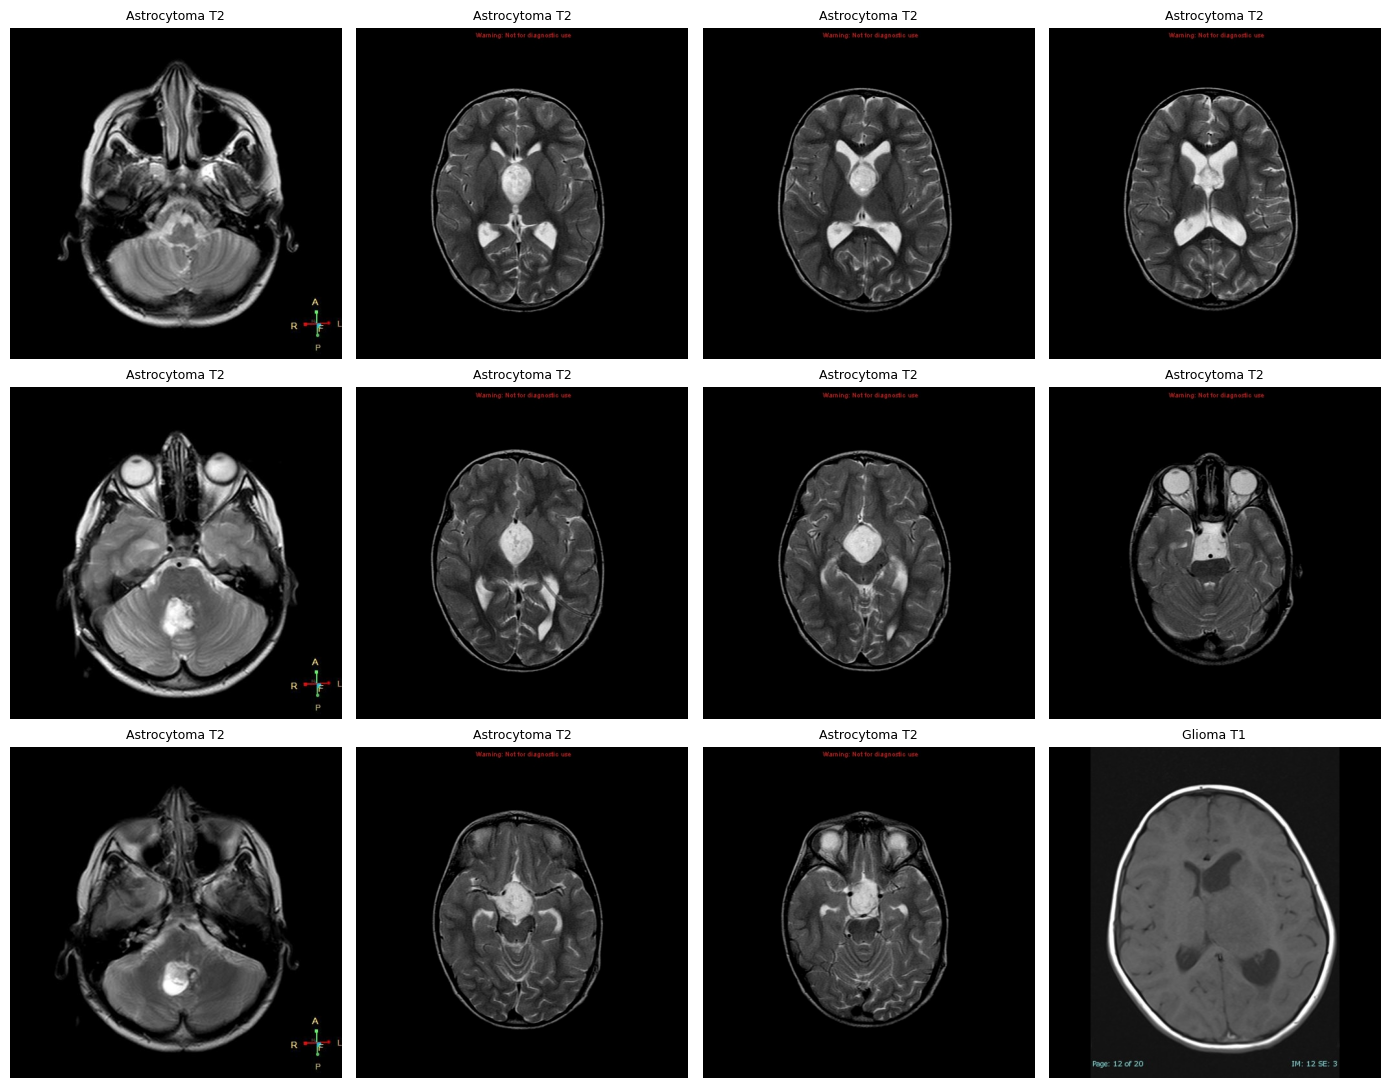

In [25]:
import matplotlib.pyplot as plt

sample_color_paths = non_grayscale["image_path_disk"].head(12)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))

for ax, relative_path in zip(axes.flat, sample_color_paths):
    path = DATA_DIR / relative_path

    with Image.open(path) as img:
        ax.imshow(img)

    ax.set_title(
        relative_path.split("/")[0],
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
non_grayscale["class"] = (
    non_grayscale["image_path_disk"]
    .str.split("/")
    .str[0]
)

non_grayscale["class"].value_counts()

/tmp/ipykernel_1508460/1292350273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_grayscale["class"] = (


class
Meningioma T1C+     64
Glioma T1C+         37
Glioma T1           34
Glioma T2           23
Meningioma T2       21
Meningioma T1       15
Astrocytoma T1      11
Astrocytoma T2      11
Astrocytoma T1C+    11
Other T2             5
Other T1C+           4
Other T1             2
Name: count, dtype: int64

In [27]:
import re

def extract_series_name(image_path):
    filename = Path(image_path.replace("\\", "/")).stem

    # Retire uniquement un numéro placé à la fin du nom
    series_name = re.sub(r"\s+\d+$", "", filename)

    return series_name.strip()

df["series_name"] = df["image_path"].apply(extract_series_name)

df[
    ["image_path", "class", "series_name"]
].head(15)

,image_path,class,series_name
0,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Astrocytoma T1,T1 - Anaplastic astrocytoma (pineal region)
1,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Astrocytoma T1,T1 - Anaplastic astrocytoma (pineal region)
2,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Astrocytoma T1,T1 - Anaplastic astrocytoma (pineal region)
3,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Astrocytoma T1,T1 - Anaplastic astrocytoma (pineal region)
4,Astrocytoma T1\T1 - Anaplastic astrocytoma fro...,Astrocytoma T1,"T1 - Anaplastic astrocytoma frontal , ventricle"
5,Astrocytoma T1\T1 - Anaplastic astrocytoma fro...,Astrocytoma T1,"T1 - Anaplastic astrocytoma frontal , ventricle"
6,Astrocytoma T1\T1 - Anaplastic astrocytoma fro...,Astrocytoma T1,"T1 - Anaplastic astrocytoma frontal , ventricle"
7,Astrocytoma T1\T1 - Anaplastic astrocytoma NOS...,Astrocytoma T1,T1 - Anaplastic astrocytoma NOS
8,Astrocytoma T1\T1 - Anaplastic astrocytoma NOS...,Astrocytoma T1,T1 - Anaplastic astrocytoma NOS
9,Astrocytoma T1\T1 - Anaplastic astrocytoma NOS...,Astrocytoma T1,T1 - Anaplastic astrocytoma NOS


In [28]:
series_counts = df["series_name"].value_counts()

print("Nombre d'images :", len(df))
print("Nombre de series_name uniques :", df["series_name"].nunique())

print("\nTaille des groupes :")
print(series_counts.describe())

print("\nSéries contenant le plus d'images :")
print(series_counts.head(20))

Nombre d'images : 11300
Nombre de series_name uniques : 709

Taille des groupes :
count    709.000000
mean      15.937941
std       20.776021
min        1.000000
25%        5.000000
50%        8.000000
75%       16.000000
max      158.000000
Name: count, dtype: float64

Séries contenant le plus d'images :
series_name
T1C+ - MRI brain - normal (70-year-old) ventricle , brainstem                                         158
T1C+ - Trigeminal schwannoma trigeminal , cerebellopontine angle                                      139
T1 - Oligodendroglioma frontal                                                                        128
T1 - MRI brain - normal (70-year-old) ventricle , brainstem                                           125
T1C+ - Solitary fibrous tumor (hemangiopericytoma) falx                                               120
T1 - Bilateral thalamic glioma ventricle                                                              109
T1C+ - Oligodendroglioma frontal             

In [29]:
def extract_case_name(series_name):
    return re.sub(
        r"^(T1C\+|T1|T2)\s*-\s*",
        "",
        series_name
    ).strip()

df["case_name"] = df["series_name"].apply(extract_case_name)

df[
    ["class", "series_name", "case_name"]
].head(15)

,class,series_name,case_name
0,Astrocytoma T1,T1 - Anaplastic astrocytoma (pineal region),Anaplastic astrocytoma (pineal region)
1,Astrocytoma T1,T1 - Anaplastic astrocytoma (pineal region),Anaplastic astrocytoma (pineal region)
2,Astrocytoma T1,T1 - Anaplastic astrocytoma (pineal region),Anaplastic astrocytoma (pineal region)
3,Astrocytoma T1,T1 - Anaplastic astrocytoma (pineal region),Anaplastic astrocytoma (pineal region)
4,Astrocytoma T1,"T1 - Anaplastic astrocytoma frontal , ventricle","Anaplastic astrocytoma frontal , ventricle"
5,Astrocytoma T1,"T1 - Anaplastic astrocytoma frontal , ventricle","Anaplastic astrocytoma frontal , ventricle"
6,Astrocytoma T1,"T1 - Anaplastic astrocytoma frontal , ventricle","Anaplastic astrocytoma frontal , ventricle"
7,Astrocytoma T1,T1 - Anaplastic astrocytoma NOS,Anaplastic astrocytoma NOS
8,Astrocytoma T1,T1 - Anaplastic astrocytoma NOS,Anaplastic astrocytoma NOS
9,Astrocytoma T1,T1 - Anaplastic astrocytoma NOS,Anaplastic astrocytoma NOS


In [30]:
case_modalities = (
    df.groupby("case_name")["modality"]
    .agg(lambda x: sorted(set(x)))
)

print("Nombre de case_name uniques :", df["case_name"].nunique())

print("\nNombre de modalités par case_name :")
print(case_modalities.apply(len).value_counts().sort_index())

print("\nExemples avec les 3 modalités :")
print(
    case_modalities[
        case_modalities.apply(len) == 3
    ].head(20)
)

Nombre de case_name uniques : 274

Nombre de modalités par case_name :
modality
1     22
2     69
3    183
Name: count, dtype: int64

Exemples avec les 3 modalités :
case_name
Acoustic neuroma cerebellopontine angle , intracanalicular    [T1, T1C+, T2]
Acoustic neuroma cerebellopontine angle , trigeminal          [T1, T1C+, T2]
Acoustic neuroma ventricle , supratentorial                   [T1, T1C+, T2]
Acoustic neuroma vestibular                                   [T1, T1C+, T2]
Acoustic schwannoma cerebellopontine angle                    [T1, T1C+, T2]
Acoustic schwannoma cerebellopontine angle , tentorial        [T1, T1C+, T2]
Acoustic schwannoma cerebellopontine angle , trigeminal       [T1, T1C+, T2]
Acoustic schwannoma cerebellopontine angle , ventricle        [T1, T1C+, T2]
Acoustic schwannoma ventricle                                 [T1, T1C+, T2]
Anaplastic astrocytoma (pineal region)                        [T1, T1C+, T2]
Anaplastic astrocytoma frontal , ventricle            

In [31]:
case_pathologies = (
    df.groupby("case_name")["pathology"]
    .nunique()
)

print(
    "case_name associés à plusieurs pathologies :",
    (case_pathologies > 1).sum()
)

case_name associés à plusieurs pathologies : 0


In [32]:
case_description_stats = (
    df.groupby("case_name")
    .agg(
        n_images=("image_path", "size"),
        n_modalities=("modality", "nunique"),
        n_descriptions=("description", "nunique")
    )
)

case_description_stats.describe()

,n_images,n_modalities,n_descriptions
count,274.000000,274.000000,274.000000
mean,41.240876,2.587591,1.317518
std,49.542083,0.635915,0.936395
min,3.000000,1.000000,1.000000
25%,13.000000,2.000000,1.000000
50%,22.000000,3.000000,1.000000
75%,44.000000,3.000000,1.000000
max,310.000000,3.000000,8.000000


In [35]:
print("Nombre de descriptions distinctes par case_name :")
print(
    case_description_stats["n_descriptions"]
    .value_counts()
    .sort_index()
)

print("\nCase_name avec plusieurs descriptions :")
display(
    case_description_stats[
        case_description_stats["n_descriptions"] > 1
    ]
    .sort_values("n_descriptions", ascending=False)
    .head(20)
)

Nombre de descriptions distinctes par case_name :
n_descriptions
1    230
2     25
3      8
4      4
5      4
6      1
7      1
8      1
Name: count, dtype: int64

Case_name avec plusieurs descriptions :


,n_images,n_modalities,n_descriptions
case_name,,,
Oligodendroglioma frontal,291,3,8
Central neurocytoma ventricle,245,3,7
"Acoustic neuroma cerebellopontine angle , intracanalicular",117,3,6
Brainstem glioma ventricle,97,3,5
"Pilocytic astrocytoma posterior fossa , ventricle",125,3,5
Meningioma frontal,227,3,5
Meningioma,218,3,5
Posterior fossa ependymoma ventricle,96,3,4
Pilocytic astrocytoma,38,3,4


In [36]:
df_with_description = df[
    ~df["description_empty"]
].copy()

case_desc_groups = (
    df_with_description
    .groupby(["case_name", "description"])
    .agg(
        n_images=("image_path", "size"),
        n_modalities=("modality", "nunique"),
        modalities=("modality", lambda x: sorted(set(x)))
    )
    .reset_index()
)

print(
    "Nombre de groupes case_name + description :",
    len(case_desc_groups)
)

print("\nNombre de modalités par groupe :")
print(
    case_desc_groups["n_modalities"]
    .value_counts()
    .sort_index()
)

print("\nTaille des groupes :")
print(case_desc_groups["n_images"].describe())

Nombre de groupes case_name + description : 358

Nombre de modalités par groupe :
n_modalities
1     31
2    100
3    227
Name: count, dtype: int64

Taille des groupes :
count    358.000000
mean      30.751397
std       36.190783
min        1.000000
25%       11.000000
50%       18.000000
75%       34.000000
max      310.000000
Name: n_images, dtype: float64


In [37]:
display(
    case_desc_groups[
        case_desc_groups["n_modalities"] == 3
    ]
    .sort_values("n_images", ascending=False)
    [["case_name", "n_images", "modalities"]]
    .head(20)
)

,case_name,n_images,modalities
165,"MRI brain - normal (70-year-old) ventricle , b...",310,"[T1, T1C+, T2]"
339,"Trigeminal schwannoma trigeminal , cerebellopo...",226,"[T1, T1C+, T2]"
284,Posterior fossa ependymoma supratentorial,192,"[T1, T1C+, T2]"
307,Solitary fibrous tumor (hemangiopericytoma) wi...,192,"[T1, T1C+, T2]"
47,Bilateral thalamic glioma ventricle,185,"[T1, T1C+, T2]"
211,Normal brain MRI with post-contrast FLAIR,163,"[T1, T1C+, T2]"
172,Meningioma,141,"[T1, T1C+, T2]"
84,"Choroid plexus carcinoma ventricle , frontal",138,"[T1, T1C+, T2]"
238,"Pediatric meningioma falx , occipital",138,"[T1, T1C+, T2]"
340,Trigeminal schwannoma ventricle,136,"[T1, T1C+, T2]"


In [38]:
case_to_check = "Bilateral thalamic glioma ventricle"

# On récupère la description la plus fréquente pour ce case_name
description_to_check = (
    df.loc[
        (df["case_name"] == case_to_check)
        & (~df["description_empty"]),
        "description"
    ]
    .value_counts()
    .index[0]
)

case_sample = df[
    (df["case_name"] == case_to_check)
    & (df["description"] == description_to_check)
]

print("Nombre d'images :", len(case_sample))

print("\nImages par modalité :")
print(case_sample["modality"].value_counts())

Nombre d'images : 185

Images par modalité :
modality
T1      95
T1C+    70
T2      20
Name: count, dtype: int64


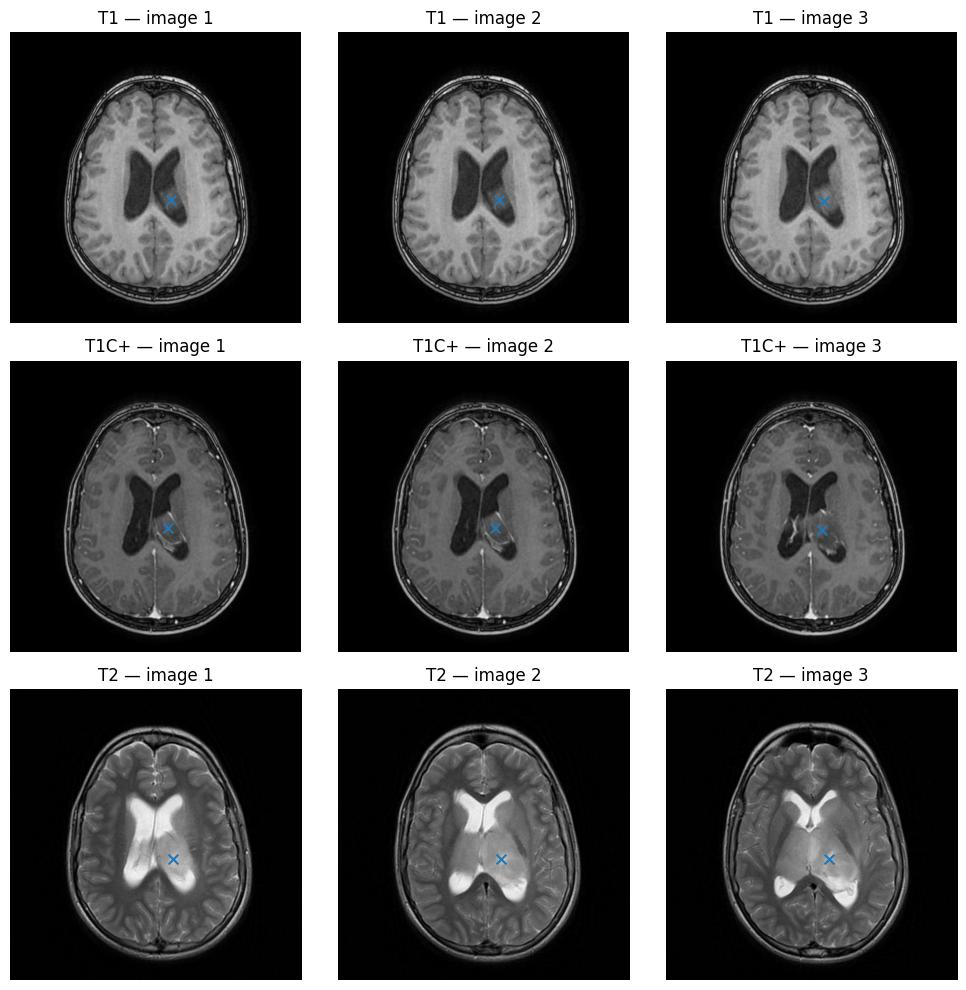

In [39]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for row, modality in enumerate(["T1", "T1C+", "T2"]):
    subset = case_sample[
        case_sample["modality"] == modality
    ].head(3)

    for col, (_, record) in enumerate(subset.iterrows()):
        relative_path = record["image_path"].replace("\\", "/")
        path = DATA_DIR / relative_path

        with Image.open(path) as img:
            axes[row, col].imshow(img)

        axes[row, col].scatter(
            record["point_x"],
            record["point_y"],
            marker="x",
            s=50
        )

        axes[row, col].set_title(
            f"{modality} — image {col + 1}"
        )
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [40]:
def extract_image_number(image_path):
    filename = Path(image_path.replace("\\", "/")).stem
    match = re.search(r"(\d+)$", filename)
    return int(match.group(1)) if match else None

df["image_number"] = df["image_path"].apply(extract_image_number)

print("Numéros manquants :", df["image_number"].isna().sum())

df[
    ["image_path", "case_name", "modality", "image_number"]
].head(10)

Numéros manquants : 0


,image_path,case_name,modality,image_number
0,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Anaplastic astrocytoma (pineal region),T1,1
1,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Anaplastic astrocytoma (pineal region),T1,2
2,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Anaplastic astrocytoma (pineal region),T1,3
3,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Anaplastic astrocytoma (pineal region),T1,4
4,Astrocytoma T1\T1 - Anaplastic astrocytoma fro...,"Anaplastic astrocytoma frontal , ventricle",T1,1
5,Astrocytoma T1\T1 - Anaplastic astrocytoma fro...,"Anaplastic astrocytoma frontal , ventricle",T1,2
6,Astrocytoma T1\T1 - Anaplastic astrocytoma fro...,"Anaplastic astrocytoma frontal , ventricle",T1,3
7,Astrocytoma T1\T1 - Anaplastic astrocytoma NOS...,Anaplastic astrocytoma NOS,T1,4
8,Astrocytoma T1\T1 - Anaplastic astrocytoma NOS...,Anaplastic astrocytoma NOS,T1,5
9,Astrocytoma T1\T1 - Anaplastic astrocytoma NOS...,Anaplastic astrocytoma NOS,T1,6


In [41]:
print("Numéros manquants :", df["image_number"].isna().sum())

Numéros manquants : 0


In [42]:
duplicates = (
    df[~df["description_empty"]]
    .groupby(
        ["case_name", "description", "modality", "image_number"]
    )
    .size()
    .reset_index(name="count")
)

duplicates = duplicates[duplicates["count"] > 1]

print("Combinaisons avec numéro dupliqué :", len(duplicates))
print(
    "Groupes case+description concernés :",
    duplicates[["case_name", "description"]]
    .drop_duplicates()
    .shape[0]
)

duplicates.sort_values("count", ascending=False).head(20)

Combinaisons avec numéro dupliqué : 0
Groupes case+description concernés : 0


,case_name,description,modality,image_number,count


In [43]:
no_desc = df[df["description_empty"]].copy()

no_desc_groups = (
    no_desc
    .groupby(["pathology", "case_name"])
    .agg(
        n_images=("image_path", "size"),
        n_modalities=("modality", "nunique"),
        modalities=("modality", lambda x: sorted(set(x))),
        min_number=("image_number", "min"),
        max_number=("image_number", "max")
    )
    .reset_index()
)

print("Images sans description :", len(no_desc))
print("Nombre de case_name :", no_desc["case_name"].nunique())

print("\nCase_name par pathologie :")
print(
    no_desc.groupby("pathology")["case_name"]
    .nunique()
)

print("\nNombre de modalités par case_name :")
print(
    no_desc_groups["n_modalities"]
    .value_counts()
    .sort_index()
)

display(
    no_desc_groups.sort_values(
        ["pathology", "n_images"],
        ascending=[True, False]
    )
)

Images sans description : 291
Nombre de case_name : 3

Case_name par pathologie :
pathology
Normal        1
Other         1
Schwannoma    1
Name: case_name, dtype: int64

Nombre de modalités par case_name :
n_modalities
2    1
3    2
Name: count, dtype: int64


,pathology,case_name,n_images,n_modalities,modalities,min_number,max_number
0,Normal,Normal brain MRI (non-focal epilepsy protocol),105,2,"[T1, T2]",36,128
1,Other,Choroid plexus carcinoma,149,3,"[T1, T1C+, T2]",50,121
2,Schwannoma,Trigeminal schwannoma,37,3,"[T1, T1C+, T2]",1,15


In [44]:
no_desc_case_names = set(no_desc["case_name"])

with_desc_same_case = (
    df[
        (df["case_name"].isin(no_desc_case_names))
        & (~df["description_empty"])
    ]
    .groupby("case_name")
    .agg(
        n_images_with_description=("image_path", "size"),
        n_descriptions=("description", "nunique"),
        modalities=("modality", lambda x: sorted(set(x)))
    )
    .sort_values("n_images_with_description", ascending=False)
)

print(
    "Case_name sans description ayant aussi des images décrites :",
    len(with_desc_same_case)
)

display(with_desc_same_case)

Case_name sans description ayant aussi des images décrites : 0


,n_images_with_description,n_descriptions,modalities
case_name,,,


In [45]:
no_desc_series = (
    no_desc
    .groupby(["case_name", "modality"])
    .agg(
        n_images=("image_path", "size"),
        min_number=("image_number", "min"),
        max_number=("image_number", "max"),
        n_unique_numbers=("image_number", "nunique")
    )
    .reset_index()
)

no_desc_series["expected_if_contiguous"] = (
    no_desc_series["max_number"]
    - no_desc_series["min_number"]
    + 1
)

no_desc_series["n_missing_inside_range"] = (
    no_desc_series["expected_if_contiguous"]
    - no_desc_series["n_unique_numbers"]
)

display(no_desc_series)

,case_name,modality,n_images,min_number,max_number,n_unique_numbers,expected_if_contiguous,n_missing_inside_range
0,Choroid plexus carcinoma,T1,55,61,115,55,55,0
1,Choroid plexus carcinoma,T1C+,39,50,88,39,39,0
2,Choroid plexus carcinoma,T2,55,67,121,55,55,0
3,Normal brain MRI (non-focal epilepsy protocol),T1,69,60,128,69,69,0
4,Normal brain MRI (non-focal epilepsy protocol),T2,36,36,71,36,36,0
5,Trigeminal schwannoma,T1,12,1,12,12,12,0
6,Trigeminal schwannoma,T1C+,10,1,10,10,10,0
7,Trigeminal schwannoma,T2,15,1,15,15,15,0


In [46]:
no_desc_duplicates = (
    no_desc
    .groupby(["case_name", "modality", "image_number"])
    .size()
    .reset_index(name="count")
)

no_desc_duplicates = no_desc_duplicates[
    no_desc_duplicates["count"] > 1
]

print(
    "Numéros dupliqués dans les séries sans description :",
    len(no_desc_duplicates)
)

display(no_desc_duplicates)

Numéros dupliqués dans les séries sans description : 0


,case_name,modality,image_number,count


In [47]:
df["case_group_key"] = np.where(
    ~df["description_empty"],
    df["case_name"] + " || " + df["description"],
    df["case_name"] + " || NO_DESCRIPTION"
)

df["case_group_id"] = pd.factorize(
    df["case_group_key"],
    sort=True
)[0]

print("Images :", len(df))
print("Case groups reconstruits :", df["case_group_id"].nunique())

print("\nTaille des groupes :")
print(
    df.groupby("case_group_id")
    .size()
    .describe()
)

Images : 11300
Case groups reconstruits : 361

Taille des groupes :
count    361.000000
mean      31.301939
std       36.780659
min        1.000000
25%       11.000000
50%       18.000000
75%       34.000000
max      310.000000
dtype: float64


In [48]:
group_pathologies = (
    df.groupby("case_group_id")["pathology"]
    .nunique()
)

print(
    "Groupes associés à plusieurs pathologies :",
    (group_pathologies > 1).sum()
)

group_modalities = (
    df.groupby("case_group_id")["modality"]
    .nunique()
)

print("\nNombre de modalités par groupe :")
print(
    group_modalities.value_counts().sort_index()
)

Groupes associés à plusieurs pathologies : 0

Nombre de modalités par groupe :
modality
1     31
2    101
3    229
Name: count, dtype: int64


In [49]:
import hashlib

def pixel_hash(path):
    with Image.open(path) as img:
        arr = np.array(img)
    return hashlib.sha256(arr.tobytes()).hexdigest()

pixel_hashes = []

for path in image_files:
    pixel_hashes.append({
        "image_path_disk": str(path.relative_to(DATA_DIR)),
        "pixel_hash": pixel_hash(path)
    })

hash_df = pd.DataFrame(pixel_hashes)

hash_counts = hash_df["pixel_hash"].value_counts()

print("Images :", len(hash_df))
print("Hashes uniques :", hash_df["pixel_hash"].nunique())
print(
    "Images appartenant à un groupe de doublons :",
    hash_df["pixel_hash"].isin(
        hash_counts[hash_counts > 1].index
    ).sum()
)

print(
    "Groupes de doublons exacts :",
    (hash_counts > 1).sum()
)

Images : 11300
Hashes uniques : 9435
Images appartenant à un groupe de doublons : 3317
Groupes de doublons exacts : 1452


In [50]:
# Relier les hashes aux métadonnées
hash_meta = hash_df.copy()

# Normalisation du séparateur pour pouvoir joindre au dataframe
hash_meta["image_path_norm"] = (
    hash_meta["image_path_disk"]
    .str.replace("\\", "/", regex=False)
)

df["image_path_norm"] = (
    df["image_path"]
    .str.replace("\\", "/", regex=False)
)

dup_df = (
    hash_meta
    .merge(
        df[
            [
                "image_path_norm",
                "pathology",
                "modality",
                "case_group_id",
                "case_name"
            ]
        ],
        on="image_path_norm",
        how="left"
    )
)

# Garder uniquement les hashes présents plusieurs fois
duplicate_hashes = hash_counts[hash_counts > 1].index
dup_df = dup_df[
    dup_df["pixel_hash"].isin(duplicate_hashes)
].copy()

duplicate_audit = (
    dup_df
    .groupby("pixel_hash")
    .agg(
        n_images=("image_path_norm", "size"),
        n_case_groups=("case_group_id", "nunique"),
        n_pathologies=("pathology", "nunique"),
        n_modalities=("modality", "nunique")
    )
)

print("Groupes de doublons :", len(duplicate_audit))

print(
    "Traversent plusieurs case_group :",
    (duplicate_audit["n_case_groups"] > 1).sum()
)

print(
    "Traversent plusieurs pathologies :",
    (duplicate_audit["n_pathologies"] > 1).sum()
)

print(
    "Traversent plusieurs modalités :",
    (duplicate_audit["n_modalities"] > 1).sum()
)

print("\nNombre d'images par groupe de doublons :")
print(
    duplicate_audit["n_images"]
    .value_counts()
    .sort_index()
)

Groupes de doublons : 1452
Traversent plusieurs case_group : 57
Traversent plusieurs pathologies : 0
Traversent plusieurs modalités : 40

Nombre d'images par groupe de doublons :
n_images
2    1140
3     239
4      54
5      13
6       4
7       1
8       1
Name: count, dtype: int64


In [51]:
cross_case_hashes = duplicate_audit[
    duplicate_audit["n_case_groups"] > 1
].index

cross_case_duplicates = (
    dup_df[
        dup_df["pixel_hash"].isin(cross_case_hashes)
    ]
    .sort_values(
        ["pixel_hash", "case_group_id", "modality"]
    )
)

print(
    "Images concernées :",
    len(cross_case_duplicates)
)

display(
    cross_case_duplicates[
        [
            "pixel_hash",
            "image_path_norm",
            "pathology",
            "modality",
            "case_group_id",
            "case_name"
        ]
    ].head(50)
)

Images concernées : 136


,pixel_hash,image_path_norm,pathology,modality,case_group_id,case_name
2247,041edc547f0e9370405823ed10c5985729810733c7ba78...,Ependymoma T2/T2 - Ependymoma posterior fossa ...,Ependymoma,T2,133.0,"Ependymoma posterior fossa , ventricle"
2282,041edc547f0e9370405823ed10c5985729810733c7ba78...,Ependymoma T2/T2 - Ependymoma posterior fossa ...,Ependymoma,T2,133.0,"Ependymoma posterior fossa , ventricle"
2041,041edc547f0e9370405823ed10c5985729810733c7ba78...,Ependymoma T2/T2 - Posterior fossa ependymoma ...,Ependymoma,T2,291.0,Posterior fossa ependymoma ventricle
2142,041edc547f0e9370405823ed10c5985729810733c7ba78...,Ependymoma T2/T2 - Posterior fossa ependymoma ...,Ependymoma,T2,291.0,Posterior fossa ependymoma ventricle
2167,041edc547f0e9370405823ed10c5985729810733c7ba78...,Ependymoma T2/T2 - Posterior fossa ependymoma ...,Ependymoma,T2,291.0,Posterior fossa ependymoma ventricle
2258,04966285f5235d7e178429124284acd4c271fbb0a79d2e...,Ependymoma T2/T2 - Ependymoma intraventricular...,Ependymoma,T2,131.0,"Ependymoma intraventricular , ventricle"
6675,04966285f5235d7e178429124284acd4c271fbb0a79d2e...,Ependymoma T1/T1 - Posterior fossa ependymoma ...,Ependymoma,T1,286.0,Posterior fossa ependymoma supratentorial
2003,0c46b96a9b81a7fb608d81dd9a636b53d7d4d45a38977e...,Ependymoma T2/T2 - Ependymoma intraventricular...,Ependymoma,T2,131.0,"Ependymoma intraventricular , ventricle"
6619,0c46b96a9b81a7fb608d81dd9a636b53d7d4d45a38977e...,Ependymoma T1/T1 - Posterior fossa ependymoma ...,Ependymoma,T1,286.0,Posterior fossa ependymoma supratentorial
10468,0d2710b0bbf3991763632c6e5ca4899169faec30f86ac6...,Oligodendroglioma T2/T2 - Oligodendroglioma fr...,Oligodendroglioma,T2,228.0,Oligodendroglioma frontal


In [52]:
cross_case_summary = (
    cross_case_duplicates
    .groupby("pixel_hash")
    .agg(
        n_images=("image_path_norm", "size"),
        case_groups=(
            "case_group_id",
            lambda x: sorted(set(x))
        ),
        case_names=(
            "case_name",
            lambda x: sorted(set(x))
        ),
        modalities=(
            "modality",
            lambda x: sorted(set(x))
        ),
        pathologies=(
            "pathology",
            lambda x: sorted(set(x))
        )
    )
)

display(cross_case_summary.head(20))

,n_images,case_groups,case_names,modalities,pathologies
pixel_hash,,,,,
041edc547f0e9370405823ed10c5985729810733c7ba787f15b6ea3239beceff,5,"[133.0, 291.0]","[Ependymoma posterior fossa , ventricle, Poste...",[T2],[Ependymoma]
04966285f5235d7e178429124284acd4c271fbb0a79d2e996cf5ea88a9bb7f0a,2,"[131.0, 286.0]","[Ependymoma intraventricular , ventricle, Post...","[T1, T2]",[Ependymoma]
0c46b96a9b81a7fb608d81dd9a636b53d7d4d45a38977ea90dd5d42f991c08c5,2,"[131.0, 286.0]","[Ependymoma intraventricular , ventricle, Post...","[T1, T2]",[Ependymoma]
0d2710b0bbf3991763632c6e5ca4899169faec30f86ac651c612d59f1590a76d,3,"[228.0, 234.0]",[Oligodendroglioma frontal],[T2],[Oligodendroglioma]
121c15ad282444ef3f8f5aa801fd67945fd05e517e760b8da25e804a85cede3b,2,"[228.0, 234.0]",[Oligodendroglioma frontal],[T1C+],[Oligodendroglioma]
195b7481c748849ce5a4207037f9fd00f56a3c227b34a1ac264706902b5a1a65,2,"[228.0, 234.0]",[Oligodendroglioma frontal],[T1],[Oligodendroglioma]
19603a97919b906a7f0e42df150cfd066dcf258f5dd46ac03fa333b8e8000254,2,"[131.0, 286.0]","[Ependymoma intraventricular , ventricle, Post...","[T1, T2]",[Ependymoma]
1ec731d3aa7834a9e8e40a4bef3585a8e4894d04d13e902e3447a9cb3bdfd8a9,2,"[228.0, 234.0]",[Oligodendroglioma frontal],[T1],[Oligodendroglioma]
1f273248567cb7ae1bb4fe6b492debdb785e05c80617fe5fb0a3879653557a24,2,"[131.0, 286.0]","[Ependymoma intraventricular , ventricle, Post...","[T1, T2]",[Ependymoma]


In [53]:
from itertools import combinations
from collections import Counter

cross_case_pairs = []

for pixel_hash, group in cross_case_duplicates.groupby("pixel_hash"):
    case_ids = sorted(group["case_group_id"].dropna().unique())

    for pair in combinations(case_ids, 2):
        cross_case_pairs.append(pair)

pair_counts = (
    pd.Series(Counter(cross_case_pairs))
    .sort_values(ascending=False)
)

print("Nombre de couples distincts :", len(pair_counts))
print("\nNombre de hashes partagés par couple :")
display(pair_counts)

Nombre de couples distincts : 4

Nombre de hashes partagés par couple :


131.0  286.0    30
228.0  234.0    22
92.0   98.0      3
133.0  291.0     2
dtype: int64

In [54]:
# ============================================================
# Construction des split_group à partir des case_group
# et des doublons exacts inter-groupes
# ============================================================

# Initialement, chaque case_group constitue son propre split_group
parent = {
    case_id: case_id
    for case_id in df["case_group_id"].dropna().unique()
}

def find(x):
    """Trouve le représentant du groupe."""
    if parent[x] != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(a, b):
    """Fusionne deux groupes."""
    root_a = find(a)
    root_b = find(b)

    if root_a != root_b:
        parent[root_b] = root_a


# Relier tous les case_group partageant au moins un doublon exact
for pixel_hash, group in cross_case_duplicates.groupby("pixel_hash"):
    case_ids = group["case_group_id"].dropna().unique()

    if len(case_ids) > 1:
        first = case_ids[0]

        for other in case_ids[1:]:
            union(first, other)


# Transformer les composantes en identifiants propres 0, 1, 2...
roots = [find(case_id) for case_id in parent]

root_to_split = {
    root: split_id
    for split_id, root in enumerate(sorted(set(roots)))
}

case_to_split = {
    case_id: root_to_split[find(case_id)]
    for case_id in parent
}

df["split_group"] = df["case_group_id"].map(case_to_split)

In [55]:
print("Case groups :", df["case_group_id"].nunique())
print("Split groups :", df["split_group"].nunique())

split_summary = (
    df.groupby("split_group")
      .agg(
          n_images=("image_path", "size"),
          n_case_groups=("case_group_id", "nunique"),
          case_groups=("case_group_id", lambda x: sorted(x.unique())),
          pathologies=("pathology", lambda x: sorted(x.unique())),
          modalities=("modality", lambda x: sorted(x.unique()))
      )
)

display(
    split_summary[
        split_summary["n_case_groups"] > 1
    ]
)

Case groups : 361
Split groups : 357


,n_images,n_case_groups,case_groups,pathologies,modalities
split_group,,,,,
92,26,2,"[92, 98]",[Other],"[T1C+, T2]"
130,276,2,"[131, 286]",[Ependymoma],"[T1, T1C+, T2]"
132,16,2,"[133, 291]",[Ependymoma],"[T1C+, T2]"
227,100,2,"[228, 234]",[Oligodendroglioma],"[T1, T1C+, T2]"


In [56]:
import imagehash

phash_rows = []

for path in image_files:
    with Image.open(path) as img:
        phash_rows.append({
            "image_path_disk": str(path.relative_to(DATA_DIR)),
            "phash": str(imagehash.phash(img))
        })

phash_df = pd.DataFrame(phash_rows)

print("Images :", len(phash_df))
print("pHash uniques :", phash_df["phash"].nunique())
phash_df.head()

Images : 11300
pHash uniques : 8359


,image_path_disk,phash
0,Astrocytoma T2/T2 - Pilocytic astrocytoma post...,ce3331cc31f2c731
1,Astrocytoma T2/T2 - Diffuse astrocytoma NOS fr...,9b996466339b8e64
2,Astrocytoma T2/T2 - Anaplastic astrocytoma par...,c71a3ac53933663a
3,Astrocytoma T2/T2 - Pilocytic astrocytoma vent...,c73338ce613d31b1
4,Astrocytoma T2/T2 - Gemistocytic astrocytoma (...,cfcc303161ce669e


In [57]:
phash_meta = phash_df.copy()

phash_meta["image_path_norm"] = (
    phash_meta["image_path_disk"]
    .str.replace("\\", "/", regex=False)
)

phash_meta = phash_meta.merge(
    df[
        [
            "image_path_norm",
            "pathology",
            "modality",
            "case_group_id",
            "split_group",
            "case_name"
        ]
    ],
    on="image_path_norm",
    how="left"
)

print("Images après jointure :", len(phash_meta))
print(
    "split_group manquants :",
    phash_meta["split_group"].isna().sum()
)

Images après jointure : 11300
split_group manquants : 22


In [58]:
missing_phash_merge = phash_meta[
    phash_meta["split_group"].isna()
]

print("Lignes non appariées :", len(missing_phash_merge))

display(
    missing_phash_merge[
        ["image_path_disk", "phash"]
    ].head(30)
)

Lignes non appariées : 22


,image_path_disk,phash
2509,"Glioma T2/T2 - Diffuse midline glioma, H3 K27M...",d29b6fe6340c641b
2560,"Glioma T2/T2 - Diffuse midline glioma, H3 K27M...",c20e6fb134c9722f
2565,"Glioma T2/T2 - Diffuse midline glioma, H3 K27M...",d29f6fd2340d641c
2595,"Glioma T2/T2 - Diffuse midline glioma, H3 K27M...",d29f6fd2340d641c
2616,"Glioma T2/T2 - Diffuse midline glioma, H3 K27M...",d29f6fd2340d641c
2625,"Glioma T2/T2 - Diffuse midline glioma, H3 K27M...",c20e6fb134c9722f
2640,"Glioma T2/T2 - Diffuse midline glioma, H3 K27M...",d29f6fd2344c6419
2689,"Glioma T2/T2 - Diffuse midline glioma, H3 K27M...",c20e6fb134c9722f
2705,"Glioma T2/T2 - Diffuse midline glioma, H3 K27M...",d21f6be0340d333b
2707,"Glioma T2/T2 - Diffuse midline glioma, H3 K27M...",929e6fc13819651f


In [59]:
def normalize_path(path):
    path = str(path).replace("\\", "/")
    path = path.replace("–", "â€“")
    return path

In [60]:
df["image_path_merge"] = (
    df["image_path"]
    .apply(normalize_path)
)

phash_meta = phash_df.copy()

phash_meta["image_path_merge"] = (
    phash_meta["image_path_disk"]
    .apply(normalize_path)
)

In [61]:
phash_meta = phash_meta.merge(
    df[
        [
            "image_path_merge",
            "pathology",
            "modality",
            "case_group_id",
            "split_group",
            "case_name"
        ]
    ],
    on="image_path_merge",
    how="left"
)

print("Images après jointure :", len(phash_meta))
print(
    "split_group manquants :",
    phash_meta["split_group"].isna().sum()
)

Images après jointure : 11300
split_group manquants : 0


In [62]:
same_phash_audit = (
    phash_meta
    .groupby("phash")
    .agg(
        n_images=("image_path_merge", "size"),
        n_split_groups=("split_group", "nunique"),
        n_pathologies=("pathology", "nunique"),
        n_modalities=("modality", "nunique")
    )
)

cross_split_same_phash = same_phash_audit[
    same_phash_audit["n_split_groups"] > 1
]

print(
    "pHash identiques traversant plusieurs split_group :",
    len(cross_split_same_phash)
)

print(
    "dont plusieurs pathologies :",
    (cross_split_same_phash["n_pathologies"] > 1).sum()
)

print(
    "dont plusieurs modalités :",
    (cross_split_same_phash["n_modalities"] > 1).sum()
)

pHash identiques traversant plusieurs split_group : 2
dont plusieurs pathologies : 2
dont plusieurs modalités : 1


In [63]:
suspect_phashes = cross_split_same_phash.index

suspect_images = (
    phash_meta[
        phash_meta["phash"].isin(suspect_phashes)
    ]
    [
        [
            "phash",
            "image_path_disk",
            "case_name",
            "pathology",
            "modality",
            "case_group_id",
            "split_group"
        ]
    ]
    .sort_values(["phash", "split_group", "modality"])
)

display(suspect_images)

,phash,image_path_disk,case_name,pathology,modality,case_group_id,split_group
7516,933b6c64319371ce,Meningioma T1C+/T1C+ - Atypical meningioma fro...,"Atypical meningioma frontal , ventricle",Meningioma,T1C+,41,41
2714,933b6c64319371ce,"Glioma T2/T2 - High-grade glioma temporal , fr...","High-grade glioma temporal , frontal",Glioma,T2,149,148
2840,933b6c64319371ce,"Glioma T2/T2 - High-grade glioma temporal , fr...","High-grade glioma temporal , frontal",Glioma,T2,149,148
8012,c23d2df034c332cf,Meningioma T1C+/T1C+ - Angiomatous meningioma ...,"Angiomatous meningioma frontal , supratentorial",Meningioma,T1C+,28,28
3256,c23d2df034c332cf,Other T1C+/T1C+ - Choroid plexus carcinoma ven...,"Choroid plexus carcinoma ventricle , frontal",Other,T1C+,84,84
3427,c23d2df034c332cf,Other T1C+/T1C+ - Choroid plexus carcinoma ven...,"Choroid plexus carcinoma ventricle , frontal",Other,T1C+,84,84



pHash : 933b6c64319371ce


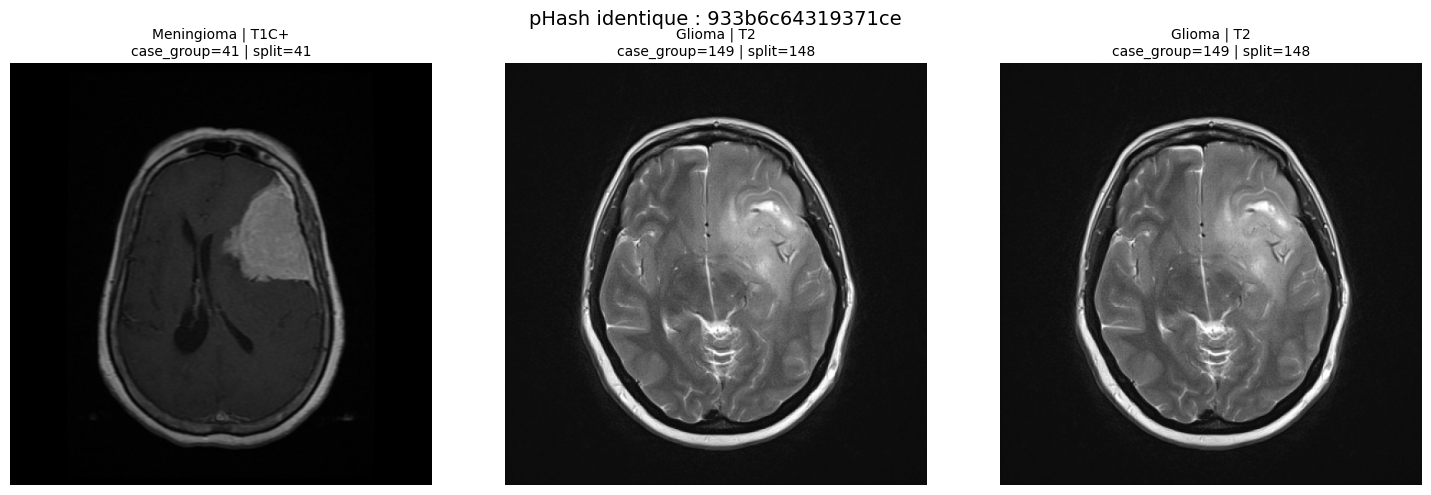


pHash : c23d2df034c332cf


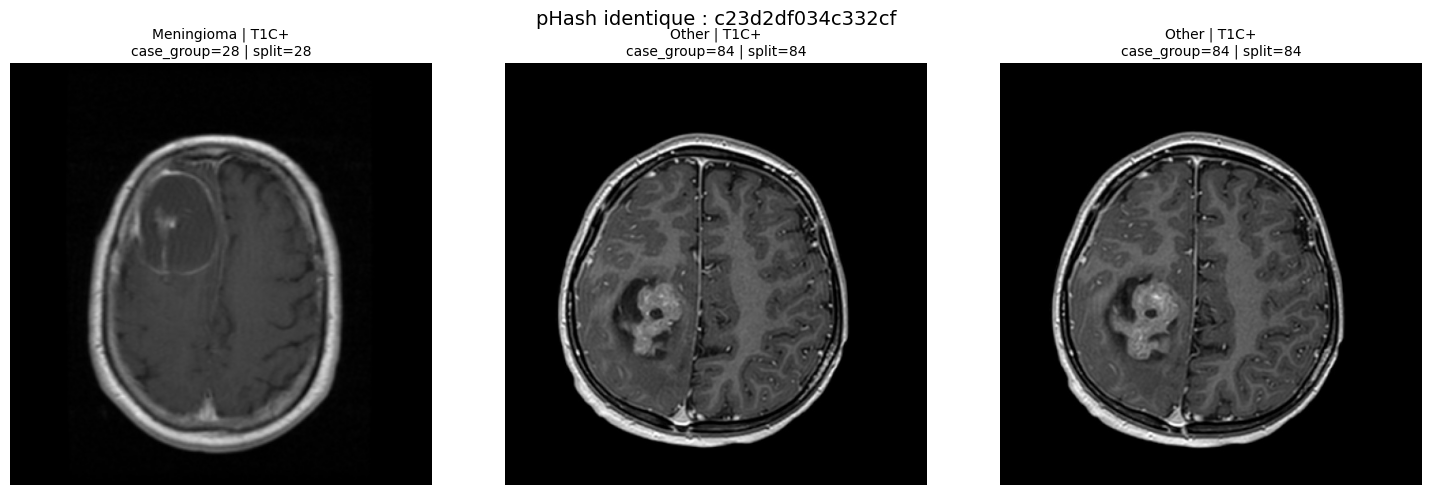

In [64]:
import matplotlib.pyplot as plt
from PIL import Image

for phash_value, group in suspect_images.groupby("phash"):

    print(f"\npHash : {phash_value}")

    fig, axes = plt.subplots(
        1,
        len(group),
        figsize=(5 * len(group), 5)
    )

    if len(group) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, group.iterrows()):

        image_path = DATA_DIR / row["image_path_disk"]

        img = Image.open(image_path)

        ax.imshow(img)
        ax.axis("off")

        ax.set_title(
            f"{row['pathology']} | {row['modality']}\n"
            f"case_group={int(row['case_group_id'])} | "
            f"split={int(row['split_group'])}",
            fontsize=10
        )

    plt.suptitle(
        f"pHash identique : {phash_value}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

In [65]:
import imagehash
from itertools import combinations

# Une seule ligne représentative par pHash
unique_phashes = (
    phash_meta[
        ["phash", "split_group", "pathology", "modality", "image_path_disk"]
    ]
    .drop_duplicates("phash")
    .reset_index(drop=True)
)

hash_objects = [
    imagehash.hex_to_hash(h)
    for h in unique_phashes["phash"]
]

candidates = []

for i, j in combinations(range(len(unique_phashes)), 2):

    # Pas besoin de comparer des images déjà protégées
    # par le même split_group
    if (
        unique_phashes.loc[i, "split_group"]
        == unique_phashes.loc[j, "split_group"]
    ):
        continue

    distance = hash_objects[i] - hash_objects[j]

    if distance <= 2:
        candidates.append({
            "distance": distance,

            "split_group_1":
                unique_phashes.loc[i, "split_group"],
            "split_group_2":
                unique_phashes.loc[j, "split_group"],

            "pathology_1":
                unique_phashes.loc[i, "pathology"],
            "pathology_2":
                unique_phashes.loc[j, "pathology"],

            "modality_1":
                unique_phashes.loc[i, "modality"],
            "modality_2":
                unique_phashes.loc[j, "modality"],

            "image_1":
                unique_phashes.loc[i, "image_path_disk"],
            "image_2":
                unique_phashes.loc[j, "image_path_disk"],
        })

near_duplicates = pd.DataFrame(candidates)

print(
    "Paires inter-split avec distance pHash <= 2 :",
    len(near_duplicates)
)

if len(near_duplicates):
    print("\nDistances :")
    print(
        near_duplicates["distance"]
        .value_counts()
        .sort_index()
    )

Paires inter-split avec distance pHash <= 2 : 19

Distances :
distance
2    19
Name: count, dtype: int64


In [66]:
display(
    near_duplicates[
        [
            "distance",
            "split_group_1",
            "split_group_2",
            "pathology_1",
            "pathology_2",
            "modality_1",
            "modality_2",
            "image_1",
            "image_2"
        ]
    ].sort_values(
        ["pathology_1", "pathology_2"]
    )
)

,distance,split_group_1,split_group_2,pathology_1,pathology_2,modality_1,modality_2,image_1,image_2
13,2,100,142,Astrocytoma,Astrocytoma,T1C+,T1C+,Astrocytoma T1C+/T1C+ - Diffuse astrocytoma ID...,Astrocytoma T1C+/T1C+ - Gemistocytic astrocyto...
0,2,322,159,Ependymoma,Meningioma,T1C+,T1C+,Ependymoma T1C+/T1C+ - Supratentorial ependymo...,Meningioma T1C+/T1C+ - Intraventricular mening...
1,2,322,159,Ependymoma,Meningioma,T1C+,T1C+,Ependymoma T1C+/T1C+ - Supratentorial ependymo...,Meningioma T1C+/T1C+ - Intraventricular mening...
16,2,130,182,Ependymoma,Meningioma,T1,T1C+,Ependymoma T1/T1 - Posterior fossa ependymoma ...,Meningioma T1C+/T1C+ - Meningioma parafalcine ...
9,2,321,323,Ependymoma,Other,T2,T2,Ependymoma T2/T2 - Supratentorial ependymoma v...,Other T2/T2 - Supratentorial meningeal hemangi...
10,2,321,323,Ependymoma,Other,T2,T2,Ependymoma T2/T2 - Supratentorial ependymoma v...,Other T2/T2 - Supratentorial meningeal hemangi...
7,2,45,327,Glioma,Glioma,T1,T1C+,Glioma T1/T1 - Bilateral thalamic glioma basal...,"Glioma T1C+/T1C+ - Thalamic glioma ventricle ,..."
8,2,45,327,Glioma,Glioma,T1,T1C+,Glioma T1/T1 - Bilateral thalamic glioma basal...,"Glioma T1C+/T1C+ - Thalamic glioma ventricle ,..."
18,2,327,45,Glioma,Glioma,T1C+,T1C+,"Glioma T1C+/T1C+ - Thalamic glioma ventricle ,...",Glioma T1C+/T1C+ - Bilateral thalamic glioma b...
11,2,148,41,Glioma,Meningioma,T2,T1C+,"Glioma T2/T2 - High-grade glioma temporal , fr...",Meningioma T1C+/T1C+ - Atypical meningioma fro...


In [67]:
print(
    "Même pathologie :",
    (near_duplicates["pathology_1"] == near_duplicates["pathology_2"]).sum()
)

print(
    "Pathologies différentes :",
    (near_duplicates["pathology_1"] != near_duplicates["pathology_2"]).sum()
)

print(
    "Même modalité :",
    (near_duplicates["modality_1"] == near_duplicates["modality_2"]).sum()
)

print(
    "Modalités différentes :",
    (near_duplicates["modality_1"] != near_duplicates["modality_2"]).sum()
)

pairs = near_duplicates.copy()

# Un couple A-B doit être considéré identique à B-A
pairs["split_pair"] = pairs.apply(
    lambda r: tuple(sorted([
        int(r["split_group_1"]),
        int(r["split_group_2"])
    ])),
    axis=1
)

print(
    "\nCouples de split_group distincts :",
    pairs["split_pair"].nunique()
)

print("\nNombre de candidats par couple :")
print(
    pairs["split_pair"]
    .value_counts()
)

Même pathologie : 6
Pathologies différentes : 13
Même modalité : 11
Modalités différentes : 8

Couples de split_group distincts : 12

Nombre de candidats par couple :
split_pair
(45, 327)     3
(159, 322)    2
(321, 323)    2
(148, 299)    2
(41, 148)     2
(28, 194)     2
(164, 217)    1
(41, 299)     1
(62, 115)     1
(100, 142)    1
(130, 182)    1
(182, 220)    1
Name: count, dtype: int64


In [68]:
# Une paire représentative pour chacun des 12 couples
representative_pairs = (
    pairs
    .drop_duplicates("split_pair")
    .sort_values("split_pair")
    .reset_index(drop=True)
)

print("Couples à inspecter :", len(representative_pairs))

Couples à inspecter : 12


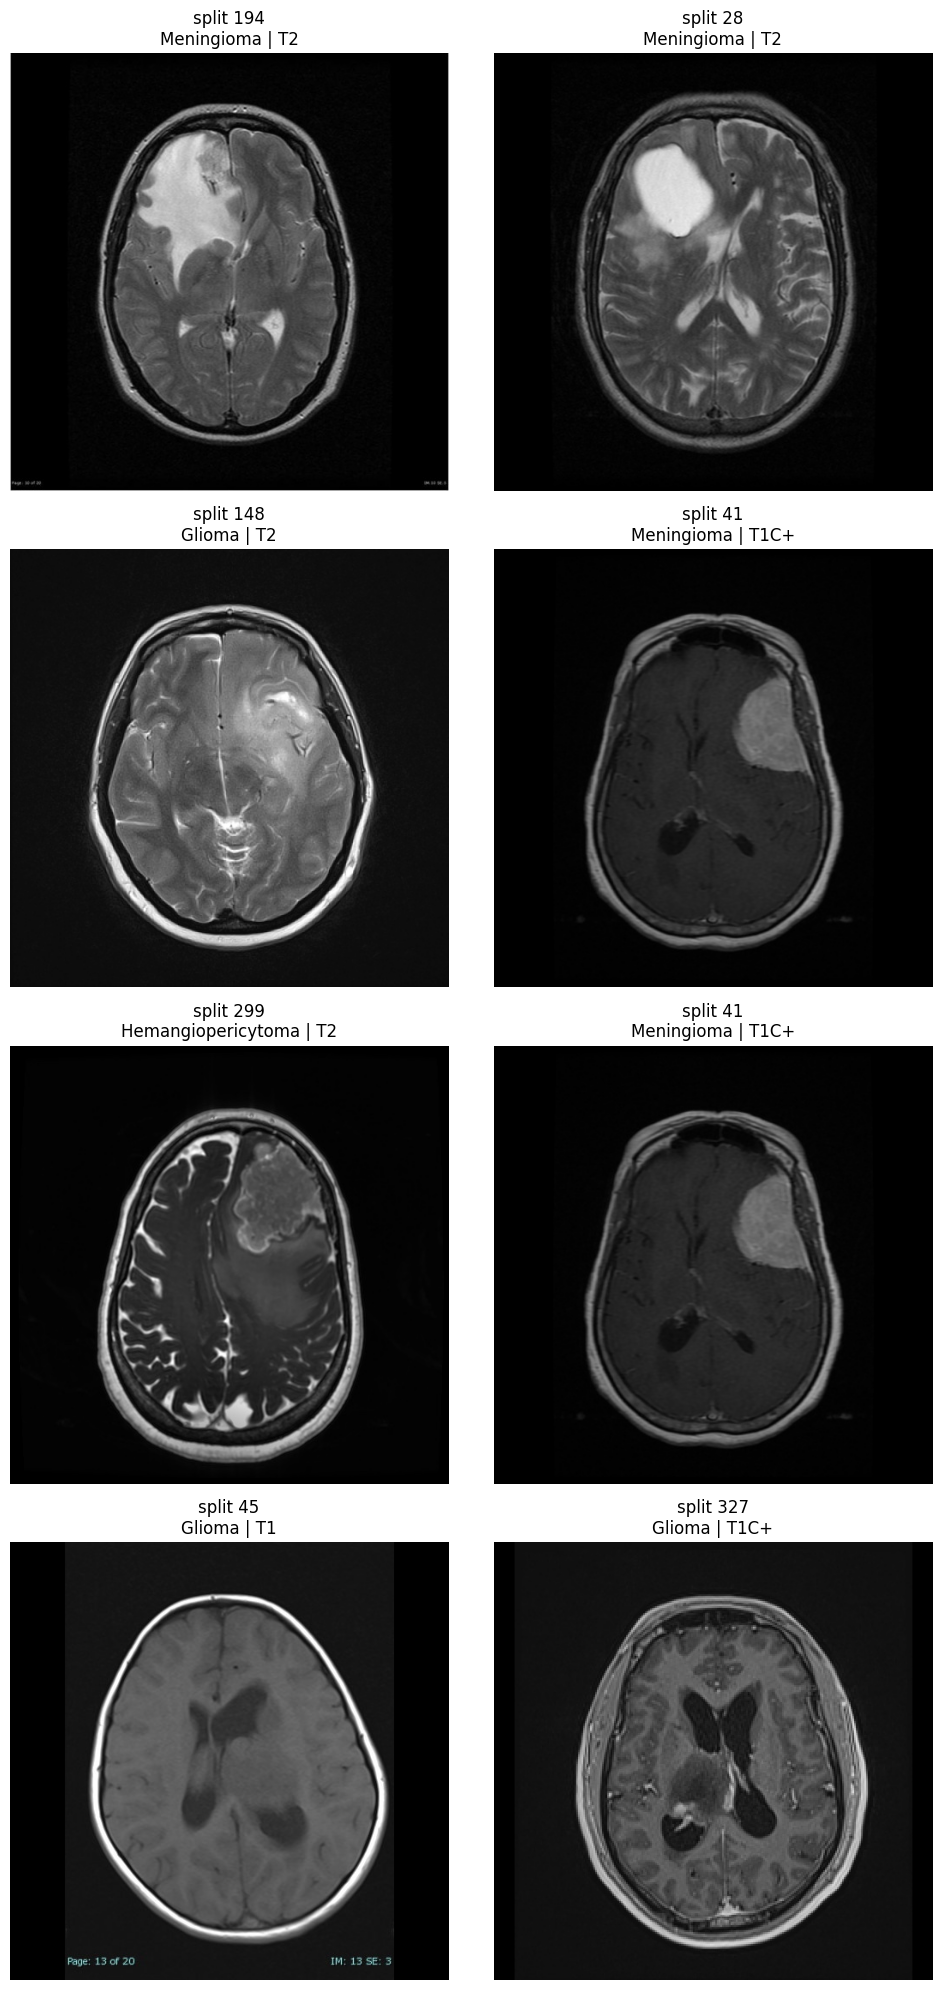

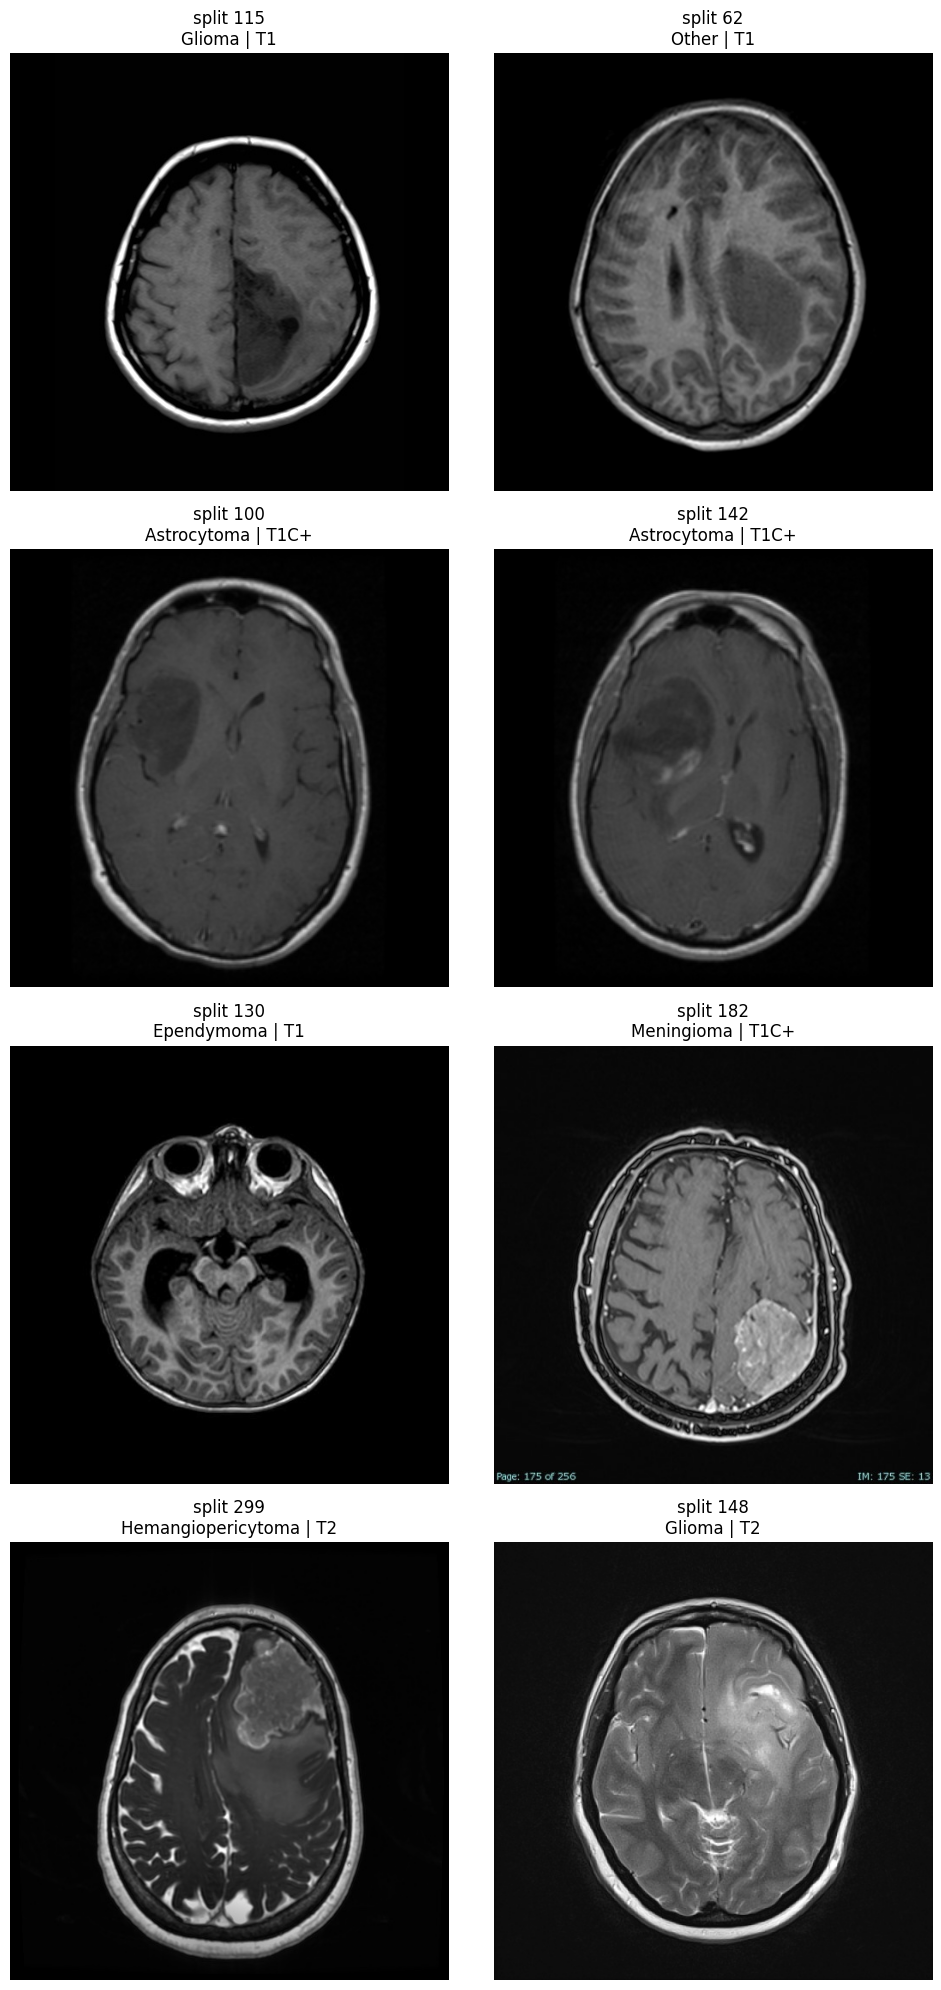

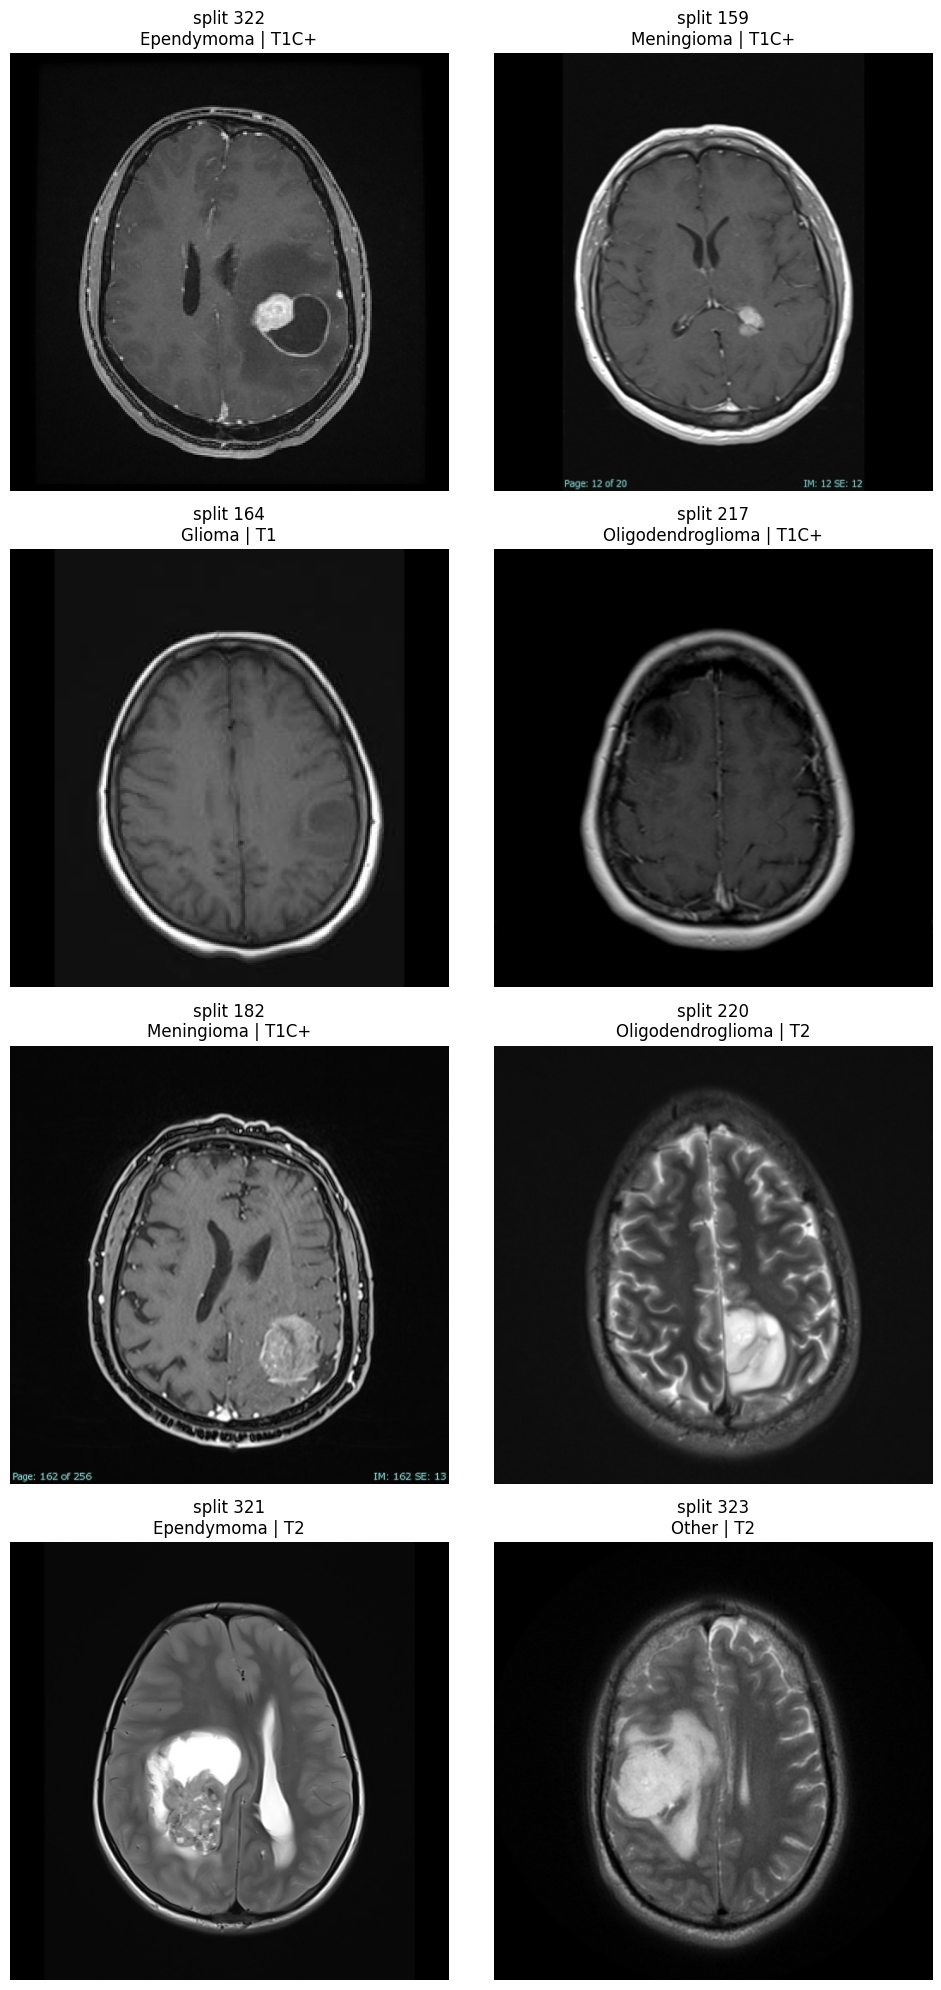

In [69]:
import matplotlib.pyplot as plt
from PIL import Image

for start in range(0, len(representative_pairs), 4):

    batch = representative_pairs.iloc[start:start + 4]

    fig, axes = plt.subplots(
        len(batch),
        2,
        figsize=(10, 5 * len(batch))
    )

    if len(batch) == 1:
        axes = [axes]

    for row_idx, (_, row) in enumerate(batch.iterrows()):

        img1 = Image.open(DATA_DIR / row["image_1"])
        img2 = Image.open(DATA_DIR / row["image_2"])

        axes[row_idx][0].imshow(img1)
        axes[row_idx][0].axis("off")
        axes[row_idx][0].set_title(
            f"split {int(row['split_group_1'])}\n"
            f"{row['pathology_1']} | {row['modality_1']}"
        )

        axes[row_idx][1].imshow(img2)
        axes[row_idx][1].axis("off")
        axes[row_idx][1].set_title(
            f"split {int(row['split_group_2'])}\n"
            f"{row['pathology_2']} | {row['modality_2']}"
        )

        # Couple affiché sur la gauche
        axes[row_idx][0].set_ylabel(
            f"{row['split_pair']}\npHash distance = {row['distance']}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

Exact pixel duplicates were identified using cryptographic image hashing. Duplicate groups spanning reconstructed case groups were merged before splitting. Perceptual hashing (pHash) was subsequently used as an audit tool for potential near-duplicates. Although 19 cross-group image pairs had a Hamming distance ≤ 2, visual inspection showed that these similarities were insufficient to establish duplicate acquisitions or shared cases. Therefore, pHash similarity alone was not used to merge additional groups.

In [70]:
# ============================================================
# Distribution des données : images vs groupes indépendants
# ============================================================

# Nombre d'images par pathologie
images_per_pathology = (
    phash_meta
    .groupby("pathology")
    .size()
    .sort_values(ascending=False)
)

# Nombre de split_group distincts par pathologie
groups_per_pathology = (
    phash_meta
    .groupby("pathology")["split_group"]
    .nunique()
    .sort_values(ascending=False)
)

distribution_pathology = (
    images_per_pathology
    .rename("n_images")
    .to_frame()
    .join(groups_per_pathology.rename("n_split_groups"))
)

distribution_pathology["images_per_group"] = (
    distribution_pathology["n_images"]
    / distribution_pathology["n_split_groups"]
)

display(distribution_pathology)

,n_images,n_split_groups,images_per_group
pathology,,,
Meningioma,2071,65,31.861538
Other,1533,57,26.894737
Glioma,1476,51,28.941176
Schwannoma,1236,40,30.900000
Astrocytoma,1118,57,19.614035
Normal,1058,14,75.571429
Ependymoma,1037,23,45.086957
Neurocytoma,618,15,41.200000
Hemangiopericytoma,603,11,54.818182


In [71]:
# ============================================================
# Distribution pathologie × modalité
# Images vs groupes indépendants
# ============================================================

# --- Nombre d'images ---
images_pathology_modality = pd.crosstab(
    phash_meta["pathology"],
    phash_meta["modality"],
    margins=True
)

print("NOMBRE D'IMAGES")
display(images_pathology_modality)


# --- Nombre de split_group distincts ---
groups_pathology_modality = (
    phash_meta
    .groupby(["pathology", "modality"])["split_group"]
    .nunique()
    .unstack(fill_value=0)
)

groups_pathology_modality["All"] = (
    phash_meta
    .groupby("pathology")["split_group"]
    .nunique()
)

groups_pathology_modality.loc["All"] = [
    phash_meta.loc[
        phash_meta["modality"] == modality,
        "split_group"
    ].nunique()
    for modality in groups_pathology_modality.columns[:-1]
] + [phash_meta["split_group"].nunique()]

print("\nNOMBRE DE SPLIT_GROUP")
display(groups_pathology_modality)

NOMBRE D'IMAGES


modality,T1,T1C+,T2,All
pathology,,,,
Astrocytoma,396,441,281,1118
Ependymoma,313,374,350,1037
Glioma,522,549,405,1476
Hemangiopericytoma,178,307,118,603
Meningioma,636,977,458,2071
Neurocytoma,190,254,174,618
Normal,415,264,379,1058
Oligodendroglioma,221,192,137,550
Other,412,756,365,1533



NOMBRE DE SPLIT_GROUP


modality,T1,T1C+,T2,All
pathology,,,,
Astrocytoma,48,51,52,57
Ependymoma,18,19,23,23
Glioma,40,41,45,51
Hemangiopericytoma,11,11,8,11
Meningioma,57,59,60,65
Neurocytoma,12,14,15,15
Normal,7,3,13,14
Oligodendroglioma,24,21,22,24
Other,44,46,43,57


In [72]:
# ============================================================
# Nombre de modalités disponibles par split_group
# ============================================================

modalities_per_group = (
    phash_meta
    .groupby(["pathology", "split_group"])["modality"]
    .nunique()
    .rename("n_modalities")
    .reset_index()
)

modality_coverage = pd.crosstab(
    modalities_per_group["pathology"],
    modalities_per_group["n_modalities"]
)

# Colonnes explicites pour faciliter la lecture
modality_coverage = modality_coverage.reindex(
    columns=[1, 2, 3],
    fill_value=0
)

modality_coverage.columns = [
    "1_modality",
    "2_modalities",
    "3_modalities"
]

modality_coverage["total_groups"] = modality_coverage.sum(axis=1)

modality_coverage["pct_3_modalities"] = (
    100
    * modality_coverage["3_modalities"]
    / modality_coverage["total_groups"]
).round(1)

display(modality_coverage)

,1_modality,2_modalities,3_modalities,total_groups,pct_3_modalities
pathology,,,,,
Astrocytoma,3,14,40,57,70.2
Ependymoma,1,7,15,23,65.2
Glioma,7,13,31,51,60.8
Hemangiopericytoma,0,3,8,11,72.7
Meningioma,2,15,48,65,73.8
Neurocytoma,0,4,11,15,73.3
Normal,7,5,2,14,14.3
Oligodendroglioma,1,3,20,24,83.3
Other,7,24,26,57,45.6


## Target definition

Although the dataset is organized into 30 folders corresponding to
10 pathologies × 3 MRI modalities (T1, T1C+, T2), modality is not
treated as part of the diagnostic target.

Exploratory analysis showed that most reconstructed case groups contain
multiple MRI modalities, with three modalities available for the majority
of groups in 8 of the 10 pathology categories.

The primary classification task is therefore defined as a 10-class
pathology classification problem.

MRI modality is retained as an acquisition variable and will be used for
stratified performance analysis rather than as a target class.

Because no reliable patient identifier is available, reconstructed
split groups are used as conservative grouping units for train,
validation and test partitioning. These groups should not be interpreted
as confirmed individual patients.

## Image appearance and artifact audit

This section investigates image-level characteristics that could act as
spurious shortcuts for the classifier, including intensity distributions,
black borders, embedded annotations and acquisition-related visual differences.

In [74]:
# ============================================================
# Statistiques d'intensité des images
# ============================================================

from PIL import Image
import numpy as np
import pandas as pd

intensity_records = []

for _, row in phash_meta.iterrows():

    image_path = DATA_DIR / row["image_path_disk"]

    with Image.open(image_path) as img:
        gray = np.asarray(img.convert("L"))

    intensity_records.append({
        "image_path_disk": row["image_path_disk"],
        "pathology": row["pathology"],
        "modality": row["modality"],
        "split_group": row["split_group"],
        "mean_intensity": gray.mean(),
        "std_intensity": gray.std(),
        "min_intensity": gray.min(),
        "max_intensity": gray.max(),
        "black_pixel_ratio": (gray <= 5).mean()
    })

intensity_df = pd.DataFrame(intensity_records)

display(intensity_df.head())

print("\nRésumé global :")
display(
    intensity_df[
        [
            "mean_intensity",
            "std_intensity",
            "black_pixel_ratio"
        ]
    ].describe()
)

,image_path_disk,pathology,modality,split_group,mean_intensity,std_intensity,min_intensity,max_intensity,black_pixel_ratio
0,Astrocytoma T2/T2 - Pilocytic astrocytoma post...,Astrocytoma,T2,254,26.252914,56.218793,0,255,0.725510
1,Astrocytoma T2/T2 - Diffuse astrocytoma NOS fr...,Astrocytoma,T2,105,32.055344,32.101378,9,255,0.000000
2,Astrocytoma T2/T2 - Anaplastic astrocytoma par...,Astrocytoma,T2,25,52.839302,59.043362,8,255,0.000000
3,Astrocytoma T2/T2 - Pilocytic astrocytoma vent...,Astrocytoma,T2,262,70.608994,76.198990,10,255,0.000000
4,Astrocytoma T2/T2 - Gemistocytic astrocytoma (...,Astrocytoma,T2,142,40.395485,57.873907,0,249,0.467007



Résumé global :


,mean_intensity,std_intensity,black_pixel_ratio
count,11300.000000,11300.000000,11300.000000
mean,40.050638,48.462266,0.358418
std,11.131526,9.044288,0.246847
min,7.695324,18.659993,0.000000
25%,32.715516,42.247697,0.101566
50%,40.114328,48.113345,0.426752
75%,46.279339,53.599764,0.565449
max,91.928768,94.648014,0.874287


In [75]:
# ============================================================
# Intensités par modalité
# ============================================================

intensity_by_modality = (
    intensity_df
    .groupby("modality")[
        ["mean_intensity", "std_intensity", "black_pixel_ratio"]
    ]
    .agg(["mean", "median", "std"])
)

display(intensity_by_modality)

mean_intensity                       std_intensity             \
                   mean     median        std          mean     median   
modality                                                                 
T1            40.452208  40.106892  11.597663     47.791048  46.972618   
T1C+          39.468538  39.783001  10.741364     47.816578  48.025135   
T2            40.473668  40.610855  11.113955     50.299559  50.492587   

                   black_pixel_ratio                      
               std              mean    median       std  
modality                                                  
T1        9.203894          0.358215  0.411894  0.231884  
T1C+      9.037774          0.382860  0.461725  0.247046  
T2        8.595718          0.320246  0.311371  0.259228

In [76]:
# ============================================================
# Intensités par pathologie
# ============================================================

intensity_by_pathology = (
    intensity_df
    .groupby("pathology")[
        ["mean_intensity", "std_intensity", "black_pixel_ratio"]
    ]
    .agg(["mean", "median", "std"])
)

display(intensity_by_pathology)

mean_intensity                       std_intensity  \
                             mean     median        std          mean   
pathology                                                               
Astrocytoma             40.758313  41.211025  10.330174     48.315232   
Ependymoma              38.333612  39.254101  13.565059     50.998356   
Glioma                  38.386554  38.170101  10.508170     47.897182   
Hemangiopericytoma      44.961296  45.195839  13.253140     48.206639   
Meningioma              39.407952  40.917824  10.180045     48.753087   
Neurocytoma             40.947423  40.120937   8.136220     49.740515   
Normal                  43.315043  43.066872  10.618686     48.449618   
Oligodendroglioma       42.516164  42.111649   9.386716     47.365305   
Other                   40.247607  38.747139  12.407322     48.741117   
Schwannoma              36.935341  36.652218   9.548279     46.293694   

                                         black_pixel_ratio                      
                       median        std              mean    median       std  
pathology                                                                       
Astrocytoma         48.619373   8.661252          0.329297  0.415043  0.255456  
Ependymoma          48.953567  11.599417          0.463964  0.516426  0.257821  
Glioma              46.795566   9.135707          0.388133  0.463196  0.221591  
Hemangiopericytoma  48.473910   9.174597          0.301907  0.429501  0.239487  
Meningioma          48.646584   7.654764          0.373958  0.443890  0.259302  
Neurocytoma         48.924708   9.019400          0.377656  0.432159  0.195018  
Normal              48.450063   8.463135          0.226667  0.141003  0.241598  
Oligodendroglioma   47.741456   7.928709          0.324581  0.440845  0.227976  
Other               48.544325   9.494639          0.394158  0.453167  0.223068  
Schwannoma          46.641114   8.654001          0.336142  0.308592  0.242528

<Figure size 1200x600 with 0 Axes>

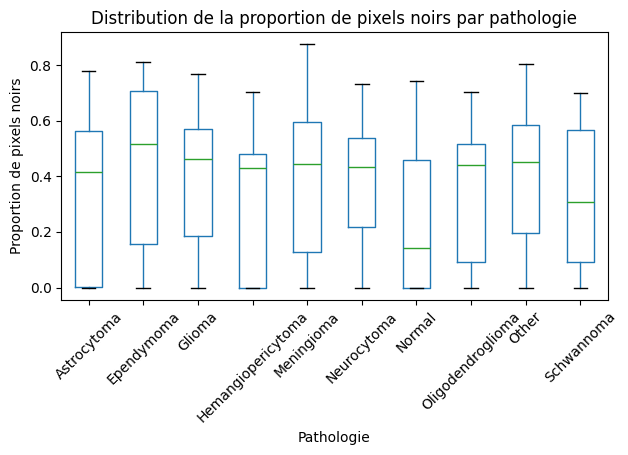

In [77]:
# ============================================================
# Distribution du fond noir par pathologie
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

intensity_df.boxplot(
    column="black_pixel_ratio",
    by="pathology",
    grid=False,
    rot=45
)

plt.title("Distribution de la proportion de pixels noirs par pathologie")
plt.suptitle("")
plt.xlabel("Pathologie")
plt.ylabel("Proportion de pixels noirs")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

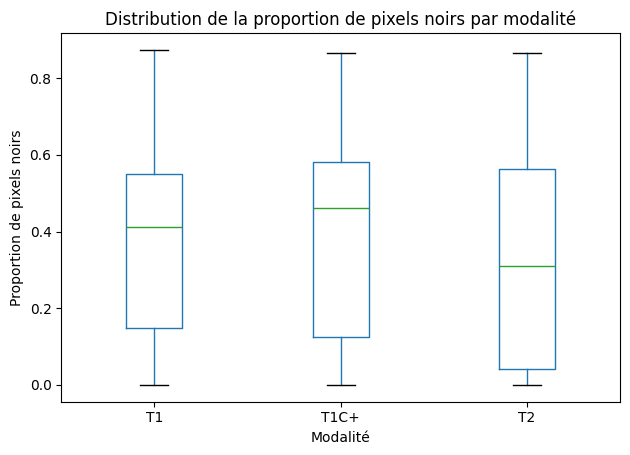

In [78]:
# ============================================================
# Distribution du fond noir par modalité
# ============================================================

plt.figure(figsize=(8, 5))

intensity_df.boxplot(
    column="black_pixel_ratio",
    by="modality",
    grid=False
)

plt.title("Distribution de la proportion de pixels noirs par modalité")
plt.suptitle("")
plt.xlabel("Modalité")
plt.ylabel("Proportion de pixels noirs")
plt.tight_layout()
plt.show()

In [79]:
# ============================================================
# Fond noir au niveau split_group
# Chaque groupe indépendant compte une seule fois
# ============================================================

group_appearance = (
    intensity_df
    .groupby(["split_group", "pathology"], as_index=False)
    .agg(
        median_black_pixel_ratio=("black_pixel_ratio", "median"),
        median_mean_intensity=("mean_intensity", "median"),
        median_std_intensity=("std_intensity", "median"),
        n_images=("image_path_disk", "size")
    )
)

print("Nombre de split_group :", len(group_appearance))

display(
    group_appearance
    .groupby("pathology")[
        ["median_black_pixel_ratio",
         "median_mean_intensity",
         "median_std_intensity"]
    ]
    .agg(["mean", "median", "std"])
)

Nombre de split_group : 357


median_black_pixel_ratio                          \
                                       mean        median       std   
pathology                                                             
Astrocytoma                        0.331415  3.946419e-01  0.231378   
Ependymoma                         0.389214  4.221420e-01  0.225465   
Glioma                             0.374918  3.902130e-01  0.214237   
Hemangiopericytoma                 0.300763  4.211617e-01  0.238819   
Meningioma                         0.371612  4.165344e-01  0.226519   
Neurocytoma                        0.385913  4.821281e-01  0.200970   
Normal                             0.125362  9.536743e-07  0.207270   
Oligodendroglioma                  0.391439  4.614830e-01  0.199658   
Other                              0.384205  4.367828e-01  0.226513   
Schwannoma                         0.291319  2.292061e-01  0.239000   

                   median_mean_intensity                        \
                                    mean     median        std   
pathology                                                        
Astrocytoma                    42.439589  41.500336  10.789954   
Ependymoma                     39.544283  41.627739  10.750111   
Glioma                         40.560414  39.417053  10.986520   
Hemangiopericytoma             47.172753  47.273979  16.053442   
Meningioma                     40.393852  42.037743   8.694664   
Neurocytoma                    42.279755  41.965679   6.655738   
Normal                         47.206612  44.110117   9.472626   
Oligodendroglioma              41.247143  40.782786   9.672044   
Other                          39.848450  38.916336  12.321326   
Schwannoma                     38.783649  37.985506   8.839755   

                   median_std_intensity                       
                                   mean     median       std  
pathology                                                     
Astrocytoma                   49.483444  49.728657  8.013379  
Ependymoma                    48.862950  48.815288  6.379397  
Glioma                        49.806714  49.554663  7.302375  
Hemangiopericytoma            49.805384  49.472007  9.763277  
Meningioma                    49.849662  50.141366  7.976313  
Neurocytoma                   50.454989  50.054495  8.138280  
Normal                        50.666980  49.819692  6.056713  
Oligodendroglioma             48.302117  47.856396  8.129251  
Other                         48.171204  48.684319  8.312531  
Schwannoma                    48.286194  48.429607  8.940757

<Figure size 1200x600 with 0 Axes>

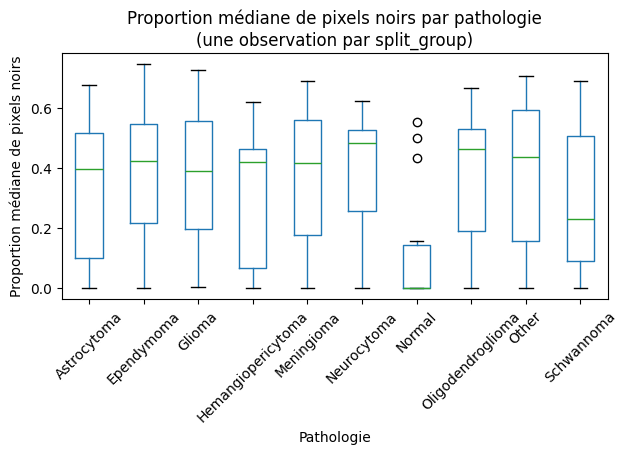

In [80]:
plt.figure(figsize=(12, 6))

group_appearance.boxplot(
    column="median_black_pixel_ratio",
    by="pathology",
    grid=False,
    rot=45
)

plt.title(
    "Proportion médiane de pixels noirs par pathologie\n"
    "(une observation par split_group)"
)
plt.suptitle("")
plt.xlabel("Pathologie")
plt.ylabel("Proportion médiane de pixels noirs")
plt.tight_layout()
plt.show()

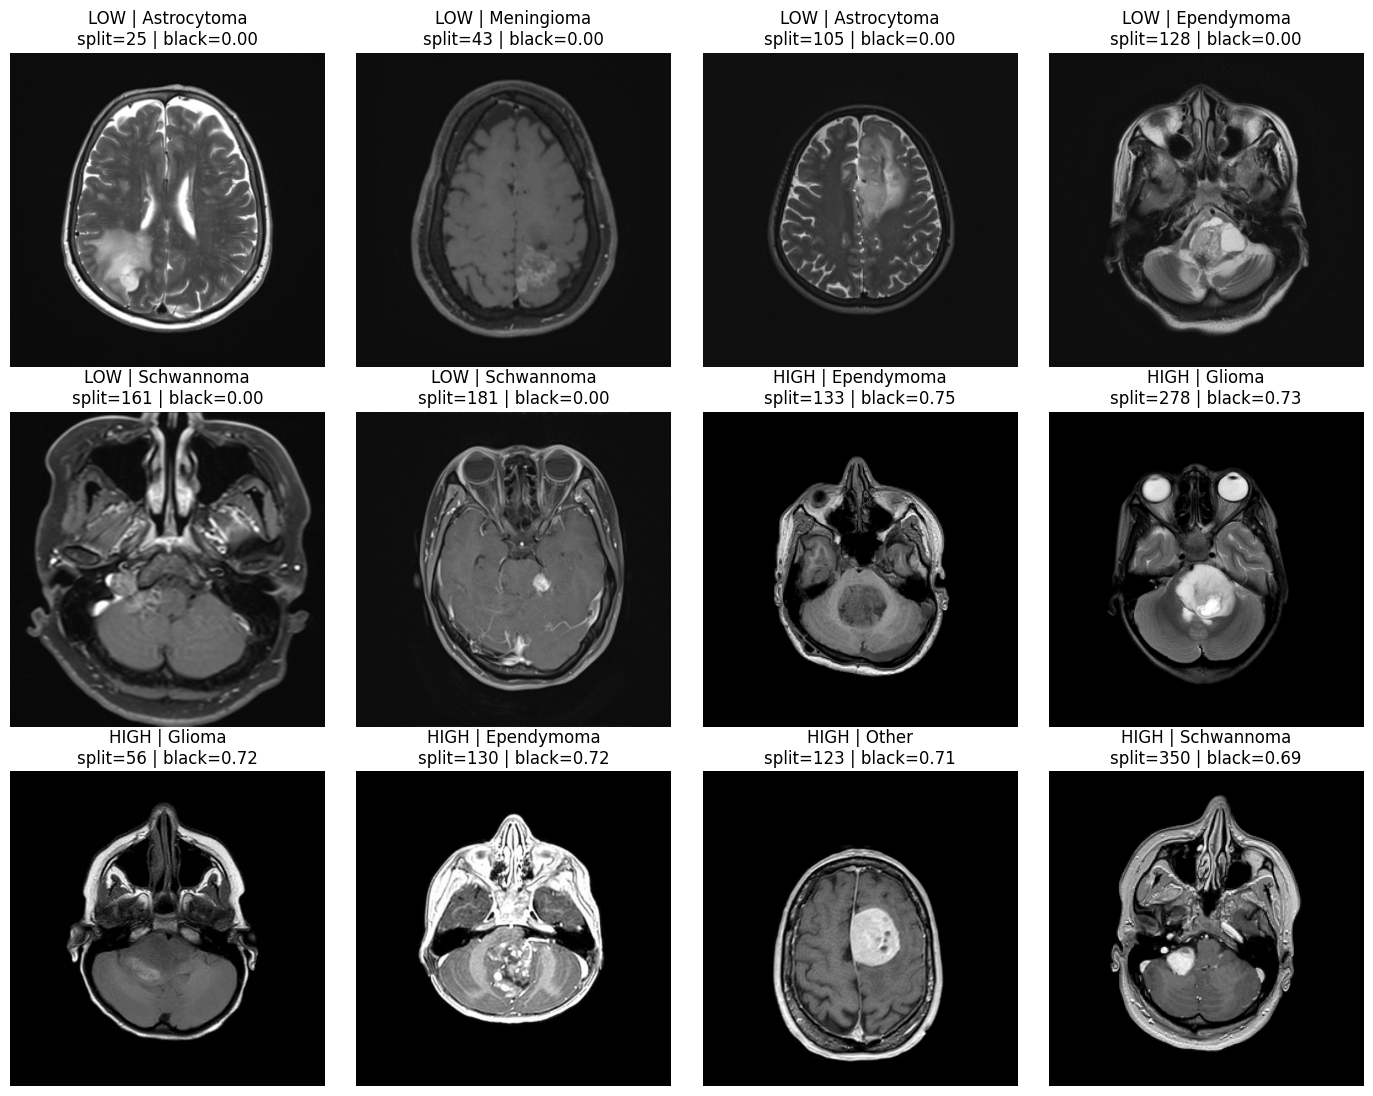

In [81]:
# ============================================================
# Inspection visuelle des groupes aux cadrages extrêmes
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image

# 6 groupes avec le moins de fond noir
lowest_groups = (
    group_appearance
    .nsmallest(6, "median_black_pixel_ratio")
)

# 6 groupes avec le plus de fond noir
highest_groups = (
    group_appearance
    .nlargest(6, "median_black_pixel_ratio")
)

extreme_groups = pd.concat([
    lowest_groups.assign(extreme="LOW"),
    highest_groups.assign(extreme="HIGH")
])

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
axes = axes.flatten()

for ax, (_, group) in zip(axes, extreme_groups.iterrows()):

    candidates = intensity_df[
        intensity_df["split_group"] == group["split_group"]
    ].copy()

    # Image dont le ratio est le plus proche
    # de la médiane du groupe
    candidates["distance_to_median"] = (
        candidates["black_pixel_ratio"]
        - group["median_black_pixel_ratio"]
    ).abs()

    representative = candidates.loc[
        candidates["distance_to_median"].idxmin()
    ]

    image_path = DATA_DIR / representative["image_path_disk"]

    with Image.open(image_path) as img:
        ax.imshow(img)

    ax.set_title(
        f'{group["extreme"]} | {group["pathology"]}\n'
        f'split={int(group["split_group"])} | '
        f'black={representative["black_pixel_ratio"]:.2f}'
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [82]:
# ============================================================
# Inspection des différents split_group Normal
# ============================================================

normal_groups = (
    group_appearance[
        group_appearance["pathology"] == "Normal"
    ]
    .sort_values("median_black_pixel_ratio")
)

display(
    normal_groups[
        [
            "split_group",
            "n_images",
            "median_black_pixel_ratio",
            "median_mean_intensity"
        ]
    ]
)

,split_group,n_images,median_black_pixel_ratio,median_mean_intensity
200,200,22,0.000000,40.817249
203,203,25,0.000000,53.258392
208,208,105,0.000000,44.526817
211,211,39,0.000000,51.506794
210,210,163,0.000000,42.594894
209,209,25,0.000000,51.879292
207,207,100,0.000000,39.900465
202,202,32,0.000002,62.511560
204,204,15,0.009766,57.339771
212,212,33,0.102955,62.858929


In [83]:
# ============================================================
# Répartition des styles de cadrage par pathologie
# au niveau split_group
# ============================================================

group_style = group_appearance[
    ["split_group", "pathology", "median_black_pixel_ratio"]
].copy()

group_style["frame_style"] = pd.cut(
    group_style["median_black_pixel_ratio"],
    bins=[-0.001, 0.05, 0.25, 0.50, 1.0],
    labels=[
        "quasi_no_black",
        "low_black",
        "medium_black",
        "high_black"
    ]
)

style_counts = pd.crosstab(
    group_style["pathology"],
    group_style["frame_style"]
)

style_pct = pd.crosstab(
    group_style["pathology"],
    group_style["frame_style"],
    normalize="index"
).mul(100).round(1)

print("Nombre de split_group :")
display(style_counts)

print("Pourcentage au sein de chaque pathologie :")
display(style_pct)

Nombre de split_group :


frame_style,quasi_no_black,low_black,medium_black,high_black
pathology,,,,
Astrocytoma,13,7,19,18
Ependymoma,2,4,10,7
Glioma,3,13,16,19
Hemangiopericytoma,3,2,4,2
Meningioma,9,12,23,21
Neurocytoma,1,3,5,6
Normal,9,2,2,1
Oligodendroglioma,2,5,10,7
Other,7,11,15,24


Pourcentage au sein de chaque pathologie :


frame_style,quasi_no_black,low_black,medium_black,high_black
pathology,,,,
Astrocytoma,22.8,12.3,33.3,31.6
Ependymoma,8.7,17.4,43.5,30.4
Glioma,5.9,25.5,31.4,37.3
Hemangiopericytoma,27.3,18.2,36.4,18.2
Meningioma,13.8,18.5,35.4,32.3
Neurocytoma,6.7,20.0,33.3,40.0
Normal,64.3,14.3,14.3,7.1
Oligodendroglioma,8.3,20.8,41.7,29.2
Other,12.3,19.3,26.3,42.1


### Conclusion — Global appearance and framing

The analysis of global image characteristics reveals substantial heterogeneity
in image framing across the dataset.

The proportion of black pixels varies considerably across reconstructed groups
and its distribution is not independent of pathology. This difference is
particularly pronounced for the Normal class: 64.3% of Normal split groups
have a median black-pixel ratio below 5%, compared with 5.9% to 27.3% for
the other classes.

However, this framing pattern is not specific to the Normal class. Images with
little or no black background are also present across several tumor categories.
Framing should therefore be considered a nuisance signal correlated with the
target rather than a deterministic class identifier.

This correlation creates a potential shortcut-learning risk: a classifier could
partially rely on acquisition, cropping, or export characteristics instead of
tumor-related visual features.

Future model evaluation should therefore account for framing characteristics
at the split-group level. The impact of image-framing standardization may also
be assessed experimentally during the modeling phase.

No transformation is applied to the raw images at this stage.

In [84]:
# ============================================================
# POINT METADATA AUDIT
# 1. Structure and completeness
# ============================================================

print("Number of images:", len(df))
print("Missing point values:", df["point"].isna().sum())

print("\nPython types found in point:")
print(df["point"].apply(type).value_counts())

print("\nFirst point values:")
display(
    df[
        ["image_path", "pathology", "modality", "point"]
    ].head(10)
)

Number of images: 11300
Missing point values: 0

Python types found in point:
point
<class 'dict'>    11300
Name: count, dtype: int64

First point values:


,image_path,pathology,modality,point
0,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Astrocytoma,T1,"{'x': 269, 'y': 286}"
1,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Astrocytoma,T1,"{'x': 260, 'y': 291}"
2,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Astrocytoma,T1,"{'x': 259, 'y': 299}"
3,Astrocytoma T1\T1 - Anaplastic astrocytoma (pi...,Astrocytoma,T1,"{'x': 259, 'y': 305}"
4,Astrocytoma T1\T1 - Anaplastic astrocytoma fro...,Astrocytoma,T1,"{'x': 267, 'y': 158}"
5,Astrocytoma T1\T1 - Anaplastic astrocytoma fro...,Astrocytoma,T1,"{'x': 272, 'y': 163}"
6,Astrocytoma T1\T1 - Anaplastic astrocytoma fro...,Astrocytoma,T1,"{'x': 276, 'y': 164}"
7,Astrocytoma T1\T1 - Anaplastic astrocytoma NOS...,Astrocytoma,T1,"{'x': 200, 'y': 322}"
8,Astrocytoma T1\T1 - Anaplastic astrocytoma NOS...,Astrocytoma,T1,"{'x': 200, 'y': 322}"
9,Astrocytoma T1\T1 - Anaplastic astrocytoma NOS...,Astrocytoma,T1,"{'x': 190, 'y': 322}"


In [85]:
# ============================================================
# POINT METADATA AUDIT
# 2. Extract coordinates and validate them
# ============================================================

df["point_x"] = df["point"].apply(
    lambda p: p.get("x") if isinstance(p, dict) else None
)

df["point_y"] = df["point"].apply(
    lambda p: p.get("y") if isinstance(p, dict) else None
)

print("Missing x coordinates:", df["point_x"].isna().sum())
print("Missing y coordinates:", df["point_y"].isna().sum())

print("\nCoordinate summary:")
display(
    df[["point_x", "point_y"]].describe()
)

# Coordinates must fall inside the corresponding image
df["point_inside_image"] = (
    df["point_x"].notna()
    & df["point_y"].notna()
    & (df["point_x"] >= 0)
    & (df["point_y"] >= 0)
    & (df["point_x"] < df["width"])
    & (df["point_y"] < df["height"])
)

print(
    "\nPoints outside image boundaries:",
    (~df["point_inside_image"]).sum()
)

display(
    df.loc[
        ~df["point_inside_image"],
        [
            "image_path",
            "pathology",
            "modality",
            "width",
            "height",
            "point_x",
            "point_y"
        ]
    ].head(20)
)

Missing x coordinates: 0
Missing y coordinates: 0

Coordinate summary:


,point_x,point_y
count,11300.000000,11300.000000
mean,253.764602,270.588673
std,50.414504,57.796866
min,101.000000,65.000000
25%,218.000000,235.000000
50%,253.000000,279.000000
75%,283.000000,312.000000
max,403.000000,460.000000



Points outside image boundaries: 0


,image_path,pathology,modality,width,height,point_x,point_y


In [86]:
# ============================================================
# POINT METADATA AUDIT
# 3. Normal-class coordinates
# ============================================================

normal_points = df.loc[
    df["pathology"] == "Normal",
    [
        "image_path",
        "split_group",
        "modality",
        "width",
        "height",
        "point_x",
        "point_y"
    ]
].copy()

print("Normal images:", len(normal_points))
print("Normal split_groups:", normal_points["split_group"].nunique())

print("\nCoordinate summary:")
display(
    normal_points[["point_x", "point_y"]].describe()
)

print("\nMost frequent coordinates:")
display(
    normal_points
    .groupby(["point_x", "point_y"])
    .size()
    .sort_values(ascending=False)
    .head(20)
    .rename("n_images")
    .reset_index()
)

print("\nNumber of distinct coordinate pairs:",
      normal_points[["point_x", "point_y"]]
      .drop_duplicates()
      .shape[0])

Normal images: 1058
Normal split_groups: 14

Coordinate summary:


,point_x,point_y
count,1058.000000,1058.000000
mean,253.537807,252.898866
std,3.164818,11.025822
min,245.000000,231.000000
25%,252.000000,245.000000
50%,253.000000,252.000000
75%,256.000000,258.000000
max,258.000000,279.000000



Most frequent coordinates:


,point_x,point_y,n_images
0,258,276,116
1,252,258,80
2,255,245,70
3,253,247,64
4,256,246,64
5,253,246,62
6,250,253,59
7,255,264,44
8,253,242,42
9,252,257,41



Number of distinct coordinate pairs: 39


In [87]:
# Geometric image center
normal_points["center_x"] = normal_points["width"] / 2
normal_points["center_y"] = normal_points["height"] / 2

normal_points["distance_to_center"] = np.sqrt(
    (normal_points["point_x"] - normal_points["center_x"]) ** 2
    + (normal_points["point_y"] - normal_points["center_y"]) ** 2
)

print("Distance to image center:")
display(normal_points["distance_to_center"].describe())

print(
    "\nExactly at (256, 256):",
    (
        (normal_points["point_x"] == 256)
        & (normal_points["point_y"] == 256)
    ).sum()
)

print(
    "Within 5 pixels of center:",
    (normal_points["distance_to_center"] <= 5).sum()
)

print(
    "Within 20 pixels of center:",
    (normal_points["distance_to_center"] <= 20).sum()
)

Distance to image center:


count    1058.000000
mean       10.591468
std         5.915553
min         1.414214
25%         6.082763
50%        10.000000
75%        14.035669
max        25.179357
Name: distance_to_center, dtype: float64


Exactly at (256, 256): 0
Within 5 pixels of center: 232
Within 20 pixels of center: 878


In [88]:
# ============================================================
# POINT METADATA AUDIT
# 4. Normal vs tumor spatial distribution
# ============================================================

df["center_x"] = df["width"] / 2
df["center_y"] = df["height"] / 2

df["distance_to_center"] = np.sqrt(
    (df["point_x"] - df["center_x"]) ** 2
    + (df["point_y"] - df["center_y"]) ** 2
)

df["is_normal"] = df["pathology"].eq("Normal")

point_comparison = (
    df.groupby("is_normal")
      .agg(
          n_images=("image_path", "size"),
          n_split_groups=("split_group", "nunique"),
          mean_x=("point_x", "mean"),
          std_x=("point_x", "std"),
          mean_y=("point_y", "mean"),
          std_y=("point_y", "std"),
          median_distance=("distance_to_center", "median"),
          mean_distance=("distance_to_center", "mean"),
          max_distance=("distance_to_center", "max")
      )
)

point_comparison.index = point_comparison.index.map({
    True: "Normal",
    False: "Tumor"
})

display(point_comparison.round(2))

,n_images,n_split_groups,mean_x,std_x,mean_y,std_y,median_distance,mean_distance,max_distance
is_normal,,,,,,,,,
Tumor,10242,343,253.79,52.94,272.42,60.31,71.37,74.12,208.08
Normal,1058,14,253.54,3.16,252.90,11.03,10.00,10.59,25.18


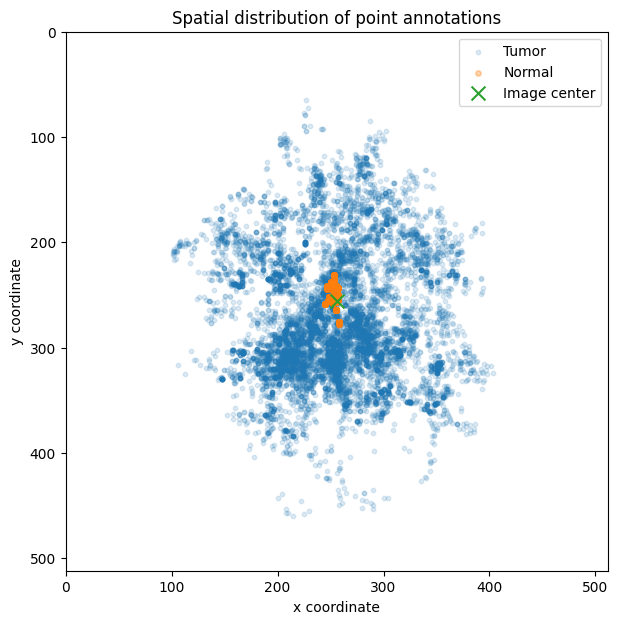

In [89]:
plt.figure(figsize=(7, 7))

tumor = df[df["pathology"] != "Normal"]
normal = df[df["pathology"] == "Normal"]

plt.scatter(
    tumor["point_x"],
    tumor["point_y"],
    alpha=0.15,
    s=10,
    label="Tumor"
)

plt.scatter(
    normal["point_x"],
    normal["point_y"],
    alpha=0.35,
    s=15,
    label="Normal"
)

plt.scatter(
    256,
    256,
    marker="x",
    s=100,
    label="Image center"
)

plt.xlim(0, 512)
plt.ylim(512, 0)

plt.xlabel("x coordinate")
plt.ylabel("y coordinate")
plt.title("Spatial distribution of point annotations")
plt.legend()

plt.show()

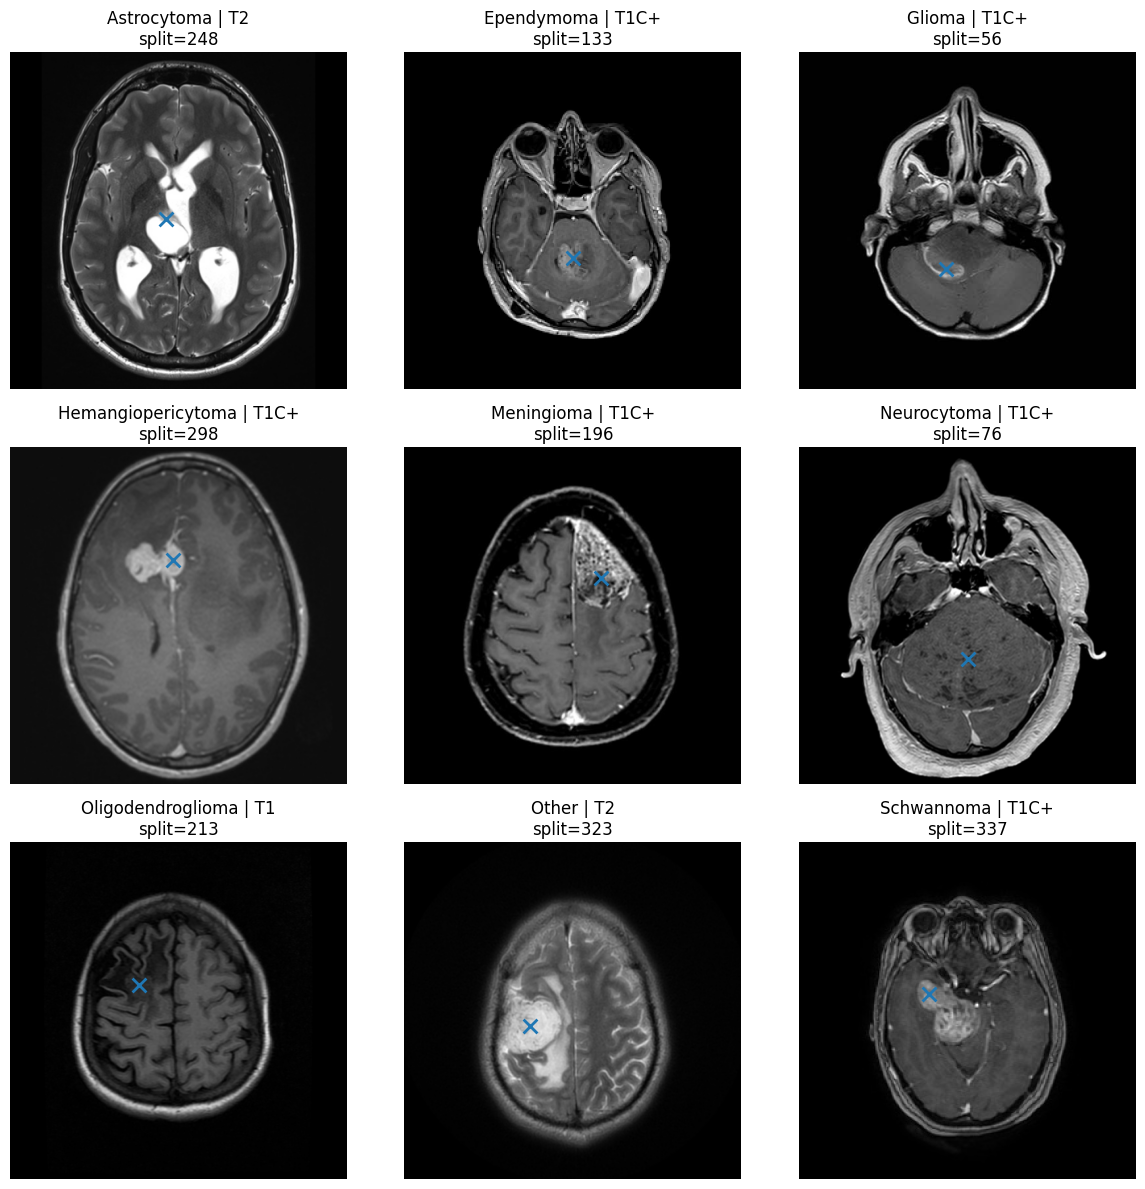

In [92]:
# ============================================================
# POINT METADATA AUDIT
# 5. Visual validation of tumor annotations
# ============================================================

tumor_df = df[df["pathology"] != "Normal"].copy()

# One random image per tumor pathology
sample_points = (
    tumor_df
    .groupby("pathology", group_keys=False)
    .sample(n=1, random_state=42)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_points.iterrows()):

    relative_path = row["image_path"].replace("\\", "/")
    image_path = DATA_DIR / relative_path

    with Image.open(image_path) as img:
        ax.imshow(img)

    ax.scatter(
        row["point_x"],
        row["point_y"],
        marker="x",
        s=100,
        linewidths=2
    )

    ax.set_title(
        f'{row["pathology"]} | {row["modality"]}\n'
        f'split={int(row["split_group"])}'
    )

    ax.axis("off")

for ax in axes[len(sample_points):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [94]:
# ============================================================
# Point annotations — within-group consistency
# ============================================================

tumor_points = df[
    df["pathology"] != "Normal"
].copy()

# Number of distinct coordinates within each split_group
point_group_summary = (
    tumor_points
    .groupby("split_group")
    .agg(
        n_images=("image_path", "size"),
        n_modalities=("modality", "nunique"),
    )
)

# Number of distinct (x, y) coordinates per split_group
unique_points = (
    tumor_points
    .groupby("split_group")
    .apply(
        lambda g: g[["point_x", "point_y"]]
        .drop_duplicates()
        .shape[0],
        include_groups=False
    )
    .rename("n_unique_points")
)

point_group_summary = point_group_summary.join(unique_points)

point_group_summary["pct_unique_points"] = (
    100
    * point_group_summary["n_unique_points"]
    / point_group_summary["n_images"]
)

print("Tumor split_groups:", len(point_group_summary))

display(
    point_group_summary[
        ["n_images", "n_modalities", "n_unique_points", "pct_unique_points"]
    ].describe()
)

print(
    "\nGroups with only one unique coordinate:",
    (point_group_summary["n_unique_points"] == 1).sum()
)

print(
    "Groups with < 10% unique coordinates:",
    (point_group_summary["pct_unique_points"] < 10).sum()
)

print(
    "Groups with >= 50% unique coordinates:",
    (point_group_summary["pct_unique_points"] >= 50).sum()
)

Tumor split_groups: 343


,n_images,n_modalities,n_unique_points,pct_unique_points
count,343.000000,343.000000,343.000000,343.000000
mean,29.860058,2.591837,20.198251,81.026333
std,34.628491,0.613820,17.267801,19.097596
min,1.000000,1.000000,1.000000,25.862069
25%,11.000000,2.000000,10.000000,72.048611
50%,18.000000,3.000000,15.000000,86.363636
75%,33.000000,3.000000,25.000000,96.352785
max,276.000000,3.000000,112.000000,100.000000



Groups with only one unique coordinate: 2
Groups with < 10% unique coordinates: 0
Groups with >= 50% unique coordinates: 309


In [95]:
# Groups with only one unique point
single_point_groups = (
    point_group_summary[
        point_group_summary["n_unique_points"] == 1
    ]
    .sort_values("n_images", ascending=False)
)

display(single_point_groups)

# Inspect their images / coordinates
single_point_ids = single_point_groups.index

display(
    tumor_points[
        tumor_points["split_group"].isin(single_point_ids)
    ][
        [
            "split_group",
            "pathology",
            "case_name",
            "modality",
            "image_number",
            "point_x",
            "point_y",
        ]
    ]
    .sort_values(["split_group", "modality", "image_number"])
)

,n_images,n_modalities,n_unique_points,pct_unique_points
split_group,,,,
18,1,1,1,100.0
271,1,1,1,100.0


,split_group,pathology,case_name,modality,image_number,point_x,point_y
10489,18,Schwannoma,Acoustic schwannoma cerebellopontine angle,T1C+,17,301,272
596,271,Astrocytoma,Pilocytic astrocytoma,T1C+,9,277,372


In [96]:
# ============================================================
# Point annotations — cross-modality consistency
# ============================================================

# Keep tumor groups containing at least two modalities
multi_modality_groups = point_group_summary[
    point_group_summary["n_modalities"] >= 2
].index

multi_points = tumor_points[
    tumor_points["split_group"].isin(multi_modality_groups)
].copy()

# Median annotation position for each split_group × modality
modality_centers = (
    multi_points
    .groupby(["split_group", "modality"])
    .agg(
        n_images=("image_path", "size"),
        median_x=("point_x", "median"),
        median_y=("point_y", "median"),
    )
    .reset_index()
)

display(modality_centers.head(10))

print(
    "Tumor groups with >= 2 modalities:",
    modality_centers["split_group"].nunique()
)

,split_group,modality,n_images,median_x,median_y
0,0,T1,5,301.0,284.0
1,0,T1C+,4,296.0,283.5
2,1,T1,5,217.0,283.0
3,1,T1C+,22,215.0,287.0
4,2,T1,6,211.0,322.0
5,2,T1C+,43,231.0,331.0
6,3,T1,5,218.0,321.0
7,3,T1C+,6,231.0,315.0
8,3,T2,4,231.5,313.0
9,4,T1,7,282.0,270.0


Tumor groups with >= 2 modalities: 320


In [97]:
from itertools import combinations
import numpy as np
import pandas as pd

modality_distances = []

for split_group, group in modality_centers.groupby("split_group"):

    for (_, row1), (_, row2) in combinations(group.iterrows(), 2):

        distance = np.sqrt(
            (row1["median_x"] - row2["median_x"]) ** 2
            +
            (row1["median_y"] - row2["median_y"]) ** 2
        )

        modality_distances.append({
            "split_group": split_group,
            "modality_1": row1["modality"],
            "modality_2": row2["modality"],
            "distance": distance
        })

modality_distances = pd.DataFrame(modality_distances)

# Standardize modality-pair names
modality_distances["modality_pair"] = modality_distances.apply(
    lambda r: " / ".join(sorted([r["modality_1"], r["modality_2"]])),
    axis=1
)

print("Number of modality comparisons:", len(modality_distances))

display(
    modality_distances["distance"].describe()
)

display(
    modality_distances
    .groupby("modality_pair")["distance"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

Number of modality comparisons: 772


count    772.000000
mean      10.989413
std       10.427268
min        0.000000
25%        4.609772
50%        8.070002
75%       14.424371
max      138.817326
Name: distance, dtype: float64

,count,mean,median,std,min,max
modality_pair,,,,,,
T1 / T1C+,251,10.99,7.78,12.13,0.0,138.82
T1 / T2,258,9.76,7.77,8.56,0.0,67.01
T1C+ / T2,263,12.20,9.00,10.23,0.5,62.29


In [98]:
# Largest cross-modality annotation discrepancies
display(
    modality_distances
    .sort_values("distance", ascending=False)
    .head(10)
)

,split_group,modality_1,modality_2,distance,modality_pair
736,340,T1,T1C+,138.817326,T1 / T1C+
609,286,T1,T2,67.007462,T1 / T2
157,75,T1C+,T2,62.289646,T1C+ / T2
390,182,T1,T1C+,58.694122,T1 / T1C+
624,293,T1,T1C+,58.662168,T1 / T1C+
626,293,T1C+,T2,56.002232,T1C+ / T2
392,182,T1C+,T2,53.600373,T1C+ / T2
610,286,T1C+,T2,52.002404,T1C+ / T2
239,114,T1C+,T2,50.104890,T1C+ / T2
735,339,T1C+,T2,49.040799,T1C+ / T2


Point annotations were available for all 11,300 images, with no missing coordinates and no points falling outside image boundaries. In tumor images, annotations showed substantial spatial variability and were visually consistent with the visible lesion location in the inspected examples. Within reconstructed tumor groups, point coordinates were highly image-specific: the median proportion of unique coordinate pairs was 86.4%, and no multi-image group used a single repeated coordinate across all images.

Normal images followed a clearly different annotation convention. Their points were concentrated near the image center (median distance: 10 pixels), consistent with the dataset documentation indicating that normal images use a central reference point rather than a lesion annotation.

Cross-modality consistency was also strong overall. Among 320 tumor groups containing at least two MRI modalities, 772 modality-pair comparisons yielded a median distance of 8.1 pixels between modality-specific median annotation locations. Median distances were similar for T1/T1C+ (7.8 px), T1/T2 (7.8 px), and T1C+/T2 (9.0 px). A small number of substantially larger discrepancies were observed, including one T1/T1C+ comparison reaching 138.8 pixels. These cases should be regarded as cross-modality outliers rather than evidence of a systematic annotation inconsistency.

Overall, the point metadata appears internally coherent and sufficiently reliable for lesion-localization analyses and for evaluating whether model attention overlaps the annotated lesion region. However, these coordinates are point-level annotations, not segmentation masks, and therefore provide localization references rather than tumor boundaries.

## Radiology description audit

In [99]:
# ============================================================
# Description audit — coverage and structure
# ============================================================

desc = df.copy()

# Normalize empty descriptions
desc["description_clean"] = (
    desc["description"]
    .astype("string")
    .str.strip()
)

desc.loc[
    desc["description_clean"].isin(["", "nan", "None"]),
    "description_clean"
] = pd.NA

has_desc = desc["description_clean"].notna()

print("Total images:", len(desc))
print("Images with description:", has_desc.sum())
print("Images without description:", (~has_desc).sum())
print(
    "Coverage:",
    f"{100 * has_desc.mean():.2f}%"
)

print(
    "\nDistinct non-null descriptions:",
    desc.loc[has_desc, "description_clean"].nunique()
)

print(
    "Tumor images without description:",
    (
        (~has_desc) &
        (desc["pathology"] != "Normal")
    ).sum()
)

print(
    "Normal images without description:",
    (
        (~has_desc) &
        (desc["pathology"] == "Normal")
    ).sum()
)

Total images: 11300
Images with description: 11009
Images without description: 291
Coverage: 97.42%

Distinct non-null descriptions: 358
Tumor images without description: 186
Normal images without description: 105


In [100]:
# ============================================================
# How descriptions are reused
# ============================================================

description_summary = (
    desc.loc[has_desc]
    .groupby("description_clean")
    .agg(
        n_images=("image_path", "size"),
        n_split_groups=("split_group", "nunique"),
        n_pathologies=("pathology", "nunique"),
        n_modalities=("modality", "nunique"),
    )
    .sort_values("n_images", ascending=False)
)

print("Description reuse summary:")

display(
    description_summary[
        ["n_images", "n_split_groups", "n_pathologies", "n_modalities"]
    ].describe()
)

print(
    "\nDescriptions used by >1 image:",
    (description_summary["n_images"] > 1).sum()
)

print(
    "Descriptions spanning >1 split_group:",
    (description_summary["n_split_groups"] > 1).sum()
)

print(
    "Descriptions spanning >1 pathology:",
    (description_summary["n_pathologies"] > 1).sum()
)

print(
    "Descriptions spanning >1 modality:",
    (description_summary["n_modalities"] > 1).sum()
)

Description reuse summary:


,n_images,n_split_groups,n_pathologies,n_modalities
count,358.000000,358.0,358.0,358.000000
mean,30.751397,1.0,1.0,2.547486
std,36.190783,0.0,0.0,0.649699
min,1.000000,1.0,1.0,1.000000
25%,11.000000,1.0,1.0,2.000000
50%,18.000000,1.0,1.0,3.000000
75%,34.000000,1.0,1.0,3.000000
max,310.000000,1.0,1.0,3.000000



Descriptions used by >1 image: 356
Descriptions spanning >1 split_group: 0
Descriptions spanning >1 pathology: 0
Descriptions spanning >1 modality: 327


In [101]:
# ============================================================
# Description audit — descriptions per split_group
# ============================================================

descriptions_per_group = (
    desc.loc[has_desc]
    .groupby("split_group")
    .agg(
        n_images=("image_path", "size"),
        n_descriptions=("description_clean", "nunique"),
        n_pathologies=("pathology", "nunique"),
        n_modalities=("modality", "nunique"),
    )
    .sort_values("n_descriptions", ascending=False)
)

print(
    "Split_groups with description:",
    len(descriptions_per_group)
)

print(
    "Split_groups with >1 description:",
    (descriptions_per_group["n_descriptions"] > 1).sum()
)

display(
    descriptions_per_group[
        descriptions_per_group["n_descriptions"] > 1
    ]
)

Split_groups with description: 354
Split_groups with >1 description: 4


,n_images,n_descriptions,n_pathologies,n_modalities
split_group,,,,
132,16,2,1,2
92,26,2,1,2
130,276,2,1,3
227,100,2,1,3


In [102]:
multi_description_groups = descriptions_per_group[
    descriptions_per_group["n_descriptions"] > 1
].index

display(
    desc[
        desc["split_group"].isin(multi_description_groups)
    ][
        [
            "split_group",
            "pathology",
            "case_name",
            "modality",
            "image_number",
            "description_clean",
        ]
    ]
    .drop_duplicates(
        ["split_group", "description_clean"]
    )
    .sort_values("split_group")
)

,split_group,pathology,case_name,modality,image_number,description_clean
9351,92,Other,Colloid cyst ventricle,T1C+,6,A rounded lesion with intermediate T1 and high...
9870,92,Other,Colloid cyst,T2,3,Mass measuring up to 2 cm at the foramen of Mo...
1210,130,Ependymoma,Posterior fossa ependymoma supratentorial,T1,1,There is a well-defined iso- to hypointense ma...
1458,130,Ependymoma,"Ependymoma intraventricular , ventricle",T1C+,1,Large size heterogeneous intraventricular mass...
1685,132,Ependymoma,Posterior fossa ependymoma ventricle,T1C+,36,Selected images from an MRI of the brain demon...
1513,132,Ependymoma,"Ependymoma posterior fossa , ventricle",T1C+,33,MRI demonstrates a posterior fossa mass center...
8097,227,Oligodendroglioma,Oligodendroglioma frontal,T1,107,Sagittal and coronal pre and post contrast CT ...
8051,227,Oligodendroglioma,Oligodendroglioma frontal,T1,61,"A mass in the left frontal lobe is present, pr..."


In [103]:
# ============================================================
# Description audit — explicit target leakage
# ============================================================

unique_descriptions = (
    desc.loc[has_desc, [
        "description_clean",
        "pathology",
        "split_group"
    ]]
    .drop_duplicates()
    .copy()
)

unique_descriptions["description_lower"] = (
    unique_descriptions["description_clean"]
    .str.lower()
)

# Direct pathology-name mention
unique_descriptions["mentions_pathology"] = (
    unique_descriptions.apply(
        lambda row:
            row["pathology"].lower()
            in row["description_lower"],
        axis=1
    )
)

print("Unique descriptions:", len(unique_descriptions))

print(
    "Descriptions explicitly mentioning their pathology:",
    unique_descriptions["mentions_pathology"].sum()
)

print(
    "Percentage:",
    f"{100 * unique_descriptions['mentions_pathology'].mean():.1f}%"
)

display(
    pd.crosstab(
        unique_descriptions["pathology"],
        unique_descriptions["mentions_pathology"],
        margins=True
    )
)

Unique descriptions: 358
Descriptions explicitly mentioning their pathology: 78
Percentage: 21.8%


mentions_pathology,False,True,All
pathology,,,
Astrocytoma,48,9,57
Ependymoma,21,4,25
Glioma,42,9,51
Hemangiopericytoma,10,1,11
Meningioma,44,21,65
Neurocytoma,11,4,15
Normal,0,13,13
Oligodendroglioma,18,7,25
Other,53,4,57


In [104]:
# ============================================================
# Description audit — class-specific vocabulary
# ============================================================

import re
from collections import Counter

STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "in", "on", "to", "with",
    "is", "are", "was", "were", "this", "that", "there", "it",
    "for", "from", "as", "at", "by", "into", "within", "which",
    "shows", "showing", "demonstrates", "demonstrating",
    "image", "images", "mri", "brain"
}

def tokenize(text):
    return [
        token
        for token in re.findall(r"[a-z]+", text.lower())
        if len(token) >= 3 and token not in STOPWORDS
    ]

rows = []

for pathology, group in unique_descriptions.groupby("pathology"):

    counts = Counter()

    for text in group["description_clean"]:
        # Count each word at most once per description
        counts.update(set(tokenize(text)))

    n_descriptions = len(group)

    for word, count in counts.most_common(15):
        rows.append({
            "pathology": pathology,
            "word": word,
            "n_descriptions": count,
            "pct_descriptions": round(
                100 * count / n_descriptions, 1
            )
        })

class_vocabulary = pd.DataFrame(rows)

for pathology in sorted(class_vocabulary["pathology"].unique()):

    print(f"\n--- {pathology} ---")

    display(
        class_vocabulary[
            class_vocabulary["pathology"] == pathology
        ][
            ["word", "n_descriptions", "pct_descriptions"]
        ]
        .reset_index(drop=True)
    )


--- Astrocytoma ---


,word,n_descriptions,pct_descriptions
0,mass,44,77.2
1,enhancement,36,63.2
2,ventricle,32,56.1
3,lesion,30,52.6
4,right,29,50.9
5,left,29,50.9
6,cystic,28,49.1
7,effect,25,43.9
8,diffusion,22,38.6
9,lateral,20,35.1



--- Ependymoma ---


,word,n_descriptions,pct_descriptions
0,mass,21,84.0
1,ventricle,17,68.0
2,hydrocephalus,15,60.0
3,enhancement,14,56.0
4,left,14,56.0
5,luschka,13,52.0
6,fourth,13,52.0
7,contrast,12,48.0
8,right,10,40.0
9,foramen,10,40.0



--- Glioma ---


...

,word,n_descriptions,pct_descriptions
0,mass,18,72.0
1,lobe,17,68.0
2,enhancement,15,60.0
3,frontal,15,60.0
4,left,15,60.0
5,right,14,56.0
6,effect,11,44.0
7,contrast,11,44.0
8,lesion,11,44.0
9,calcification,9,36.0



--- Other ---


,word,n_descriptions,pct_descriptions
0,mass,39,68.4
1,enhancement,36,63.2
2,right,34,59.6
3,lesion,30,52.6
4,signal,29,50.9
5,effect,28,49.1
6,flair,27,47.4
7,ventricle,27,47.4
8,edema,27,47.4
9,lateral,27,47.4



--- Schwannoma ---


,word,n_descriptions,pct_descriptions
0,mass,35,89.7
1,right,28,71.8
2,angle,28,71.8
3,lesion,26,66.7
4,enhancement,25,64.1
5,internal,25,64.1
6,cerebellopontine,25,64.1
7,left,21,53.8
8,ventricle,20,51.3
9,contrast,20,51.3


### Description audit — conclusions

- Radiology descriptions are available for 11,009/11,300 images (97.4%) and correspond to 358 distinct non-null descriptions.
- Description reuse is strongly structured by `split_group`: no identical description spans multiple split groups or pathology labels, while most descriptions are reused across multiple MRI modalities within the same group.
- Only 4 split groups contain more than one distinct description, suggesting that `split_group` generally represents a coherent underlying radiological case.
- 78/358 unique descriptions (21.8%) explicitly mention their assigned pathology label. However, direct label mentions substantially underestimate the diagnostic information contained in the text.
- Class-specific vocabulary reveals clinically informative patterns even when the pathology name itself is absent. Examples include `dural` / `extra axial` for meningioma, `fourth` / `luschka` / `ventricle` for ependymoma, `cerebellopontine` / `angle` for schwannoma, and `calcification` / `frontal` for oligodendroglioma.
- Normal-case descriptions are particularly explicit: 12/13 unique Normal descriptions contain the word `normal`, while additional terms such as `unremarkable` also directly indicate the absence of pathology.
- Therefore, the radiology descriptions constitute a strong potential source of target leakage for an image-classification task and will not be used as model inputs.
- They will instead be retained as metadata for dataset auditing and downstream qualitative error analysis.

## Data audit conclusions and modeling implications

### Target definition

Although the dataset is organized into 30 folders corresponding to 10 pathology
categories × 3 MRI modalities (T1, T1C+, T2), MRI modality is not considered
part of the diagnostic target.

The classification task will therefore be formulated as a **10-class pathology
classification problem**:

- Astrocytoma
- Ependymoma
- Glioma
- Hemangiopericytoma
- Meningioma
- Neurocytoma
- Normal
- Oligodendroglioma
- Other
- Schwannoma

MRI modality will be retained as metadata and used for modality-specific
performance analysis.

This formulation avoids treating different MRI acquisitions of the same
pathology as distinct diagnostic outcomes.

### Leakage prevention and future split strategy

The dataset contains multiple images that are not statistically independent.
Images belonging to the same reconstructed case may include multiple slices
and multiple MRI modalities.

A total of **357 `split_group` units** were reconstructed during the audit.
These groups incorporate case-level information as well as relationships
identified through exact duplicate analysis.

Several exact and near-duplicate relationships were also identified across
the original dataset structure, confirming that an image-level random split
would create a substantial risk of data leakage.

Therefore, future train/validation/test partitions must be performed at the
**`split_group` level**, not at the individual-image level.

All images belonging to a given `split_group` must remain entirely within a
single partition.

The final splitting procedure should additionally account for pathology
distribution and group size, since the number and size of reconstructed groups
vary substantially across pathology categories.

### Metadata usage

Several metadata fields contain information that should not be used as direct
inputs to the image classifier.

- `description` contains substantial diagnostic information and represents a
  strong source of potential target leakage. It will be retained only for
  dataset auditing and qualitative error analysis.

- `point` provides lesion-location information for tumor images, while Normal
  images use points concentrated near the image center. Point coordinates will
  therefore not be used as classification features. They will instead be
  retained as auxiliary annotations for future explainability/localization
  evaluation.

- `modality` will not be part of the classification target. It will be retained
  for subgroup performance analysis.

- `case_name`, filenames, paths, and reconstructed grouping identifiers will
  not be used as predictive features.

The primary classifier will therefore learn from **MRI image content only**.

### Dataset limitations and identified risks

The data audit identified several limitations that must be considered when
interpreting future model performance.

#### Absence of verified patient identifiers

The dataset does not provide explicit patient identifiers. Case relationships
were therefore reconstructed from the available metadata, filename structure,
image sequences, and exact duplicate relationships.

The resulting 357 `split_group` units provide a substantially safer basis for
data partitioning than individual images, but they should be interpreted as
reconstructed case/group proxies rather than confirmed patient identities.

Consequently, patient-level independence between future train, validation, and
test sets cannot be formally guaranteed.

#### Exact duplicates and highly similar MRI images

Exact duplicate analysis identified substantial redundancy in the dataset:
11,300 images correspond to 9,435 unique pixel-level images.

Exact duplicate relationships crossing the initially reconstructed groups were
used to strengthen the `split_group` definition.

Perceptual-hash analysis also identified visually similar candidates across
groups. Manual inspection showed that these candidates were generally distinct
MRI images rather than convincing duplicates, illustrating the limitations of
perceptual hashing for structurally similar medical images.

#### Framing and preprocessing heterogeneity

MRI images exhibit substantial variation in framing and background composition,
including large differences in the proportion of black pixels.

These characteristics are not uniformly distributed across pathology classes.
Normal images are particularly distinct, with a much larger proportion of
reconstructed groups exhibiting little or no black background.

This creates a potential shortcut-learning risk: a classifier may partially
exploit acquisition, framing, or preprocessing characteristics rather than
pathology-related visual features.

Future experiments should therefore evaluate model performance and behavior
with this potential confounding factor in mind.

#### Limited number of independent groups

Although the dataset contains 11,300 images, only 357 reconstructed
`split_group` units were identified.

The effective number of independent groups is therefore substantially smaller
than the raw image count and varies considerably across pathology categories.
Some classes contain only a small number of reconstructed groups despite
having hundreds or more than one thousand images.

Future evaluation metrics must consequently be interpreted in the context of
this limited and uneven case-level sample size.

#### Point annotations are not segmentation masks

The provided `point` metadata represents a lesion-location point rather than
a pixel-level tumor boundary.

The annotations were found to be internally coherent and useful for
localization-oriented evaluation, but they cannot support segmentation metrics
such as Dice score or IoU.

#### Diagnostic metadata leakage

Radiology descriptions contain strong pathology-related information, both
through explicit diagnostic labels and through class-specific clinical
vocabulary.

Using these descriptions as inputs would therefore change the task from
image-only classification and introduce substantial target leakage into the
planned benchmark.

Descriptions will consequently remain excluded from model inputs.

### Final data audit conclusions

The audit revealed that this dataset is substantially more complex than its
initial structure of 11,300 images across 30 folders suggests.

The final classification problem will be formulated as a 10-class pathology
task, with MRI modality retained as metadata rather than included in the
prediction target.

A major methodological concern is the non-independence of individual images.
Case reconstruction and duplicate analysis resulted in 357 `split_group`
units, which will be used as the basis for leakage-aware dataset partitioning.
Because explicit patient identifiers are unavailable, these groups should be
considered reconstructed case proxies rather than verified patient identities.

The audit also identified substantial exact-image redundancy, heterogeneous
image framing, uneven effective sample sizes across pathologies, and
pathology-associated differences in background composition. These factors
create potential shortcut-learning and evaluation risks that must be considered
when interpreting future model performance.

The provided lesion-point annotations were found to be sufficiently coherent
for future localization and explainability analyses, while radiology
descriptions were identified as a strong source of diagnostic information and
will therefore be excluded from image-classification inputs.

Overall, the dataset is suitable for experimental image-classification research
provided that future experiments use group-aware splitting, carefully evaluate
performance across pathology and MRI modality, and explicitly acknowledge the
remaining uncertainty regarding true patient-level independence.

The next stage of the project will construct reproducible train, validation,
and test partitions from the audited dataset before model development begins.